<a href="https://colab.research.google.com/github/OlenaMartus/Enhanced-Buckley-Leverett-Welge-Solver/blob/main/%D0%90verage_Ed_on_GitHub.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Install and Import Necessary Libraries

First, we'll import the necessary libraries in Google Colab. If you don’t have these libraries installed, Colab usually has them pre-installed.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from numpy.polynomial import Polynomial

In [ ]:
# ==============================================================================
# STEP 3: Corey Exponents Inputs for Facies (Sandstone & Siltstone)
# ==============================================================================

# 1. Фіксований кут змочування для всіх фацій (згідно з Атласом родовищ)
theta_deg_wetting = 30  # Strongly water-wet (Гнатівка/Молчанівка)

# 2. Визначення цільових показників Корі для трьох фацій
# Фація 1: Пісковик середньозернистий (Випадок 1)
n_corey_fac1_target = 2.0
m_corey_fac1_target = 2.5

# Фація 2: Пісковик дрібнозернистий (Випадок 2)
n_corey_fac2_target = 2.5
m_corey_fac2_target = 2.0

# Фація 3: Алевроліт (Випадок 3)
n_corey_fac3_target = 3.0
m_corey_fac3_target = 2.0


# 3. Автоматичний розрахунок емпіричних коефіцієнтів alpha та beta
# Формули: alpha = n / theta;  beta = m / (90 - theta)

# Коефіцієнти для Фації 1 (Пісковик середньозернистий)
alpha_fac1 = n_corey_fac1_target / theta_deg_wetting
beta_fac1 = m_corey_fac1_target / (90 - theta_deg_wetting)

# Коефіцієнти для Фації 2 (Пісковик дрібнозернистий)
alpha_fac2 = n_corey_fac2_target / theta_deg_wetting
beta_fac2 = m_corey_fac2_target / (90 - theta_deg_wetting)

# Коефіцієнти для Фації 3 (Алевроліт)
alpha_fac3 = n_corey_fac3_target / theta_deg_wetting
beta_fac3 = m_corey_fac3_target / (90 - theta_deg_wetting)


# 4. Фінальний розрахунок експонент Корі (для перевірки в моделі)
n_corey_1 = alpha_fac1 * theta_deg_wetting
m_corey_1 = beta_fac1 * (90 - theta_deg_wetting)

n_corey_2 = alpha_fac2 * theta_deg_wetting
m_corey_2 = beta_fac2 * (90 - theta_deg_wetting)

n_corey_3 = alpha_fac3 * theta_deg_wetting
m_corey_3 = beta_fac3 * (90 - theta_deg_wetting)


# 5. Візуалізація вхідних даних у вигляді таблиці Pandas
facies_data = {
    'Facies / Litology': [
        'Пісковик середньозернистий (Випадок 1)',
        'Пісковик дрібнозернистий (Випадок 2)',
        'Алевроліт (Випадок 3)'
    ],
    'Wetting Angle (theta)': [theta_deg_wetting, theta_deg_wetting, theta_deg_wetting],
    'Alpha (α)': [round(alpha_fac1, 4), round(alpha_fac2, 4), round(alpha_fac3, 4)],
    'Beta (β)': [round(beta_fac1, 4), round(beta_fac2, 4), round(beta_fac3, 4)],
    'Calculated n_corey (Oil)': [n_corey_1, n_corey_2, n_corey_3],
    'Calculated m_corey (Water)': [m_corey_1, m_corey_2, m_corey_3]
}

df_facies_inputs = pd.DataFrame(facies_data)
df_facies_inputs

,Facies / Litology,Wetting Angle (theta),Alpha (α),Beta (β),Calculated n_corey (Oil),Calculated m_corey (Water)
0,Пісковик середньозернистий (Випадок 1),30,0.066700,0.041700,2.000000,2.500000
1,Пісковик дрібнозернистий (Випадок 2),30,0.083300,0.033300,2.500000,2.000000
2,Алевроліт (Випадок 3),30,0.100000,0.033300,3.000000,2.000000


In [ ]:
# =========================================================
# БЛОК СЕРЕДНЬОЗВАЖЕНИХ ФАЦІЄСПЕЦИФІЧНИХ ПАРАМЕТРІВ
# ВСТАВИТИ ПЕРЕД СТАРИМ КОДОМ
# =========================================================

import numpy as np

# ---------------------------------------------------------
# ВВІД ДАНИХ ПО ФАЦІЯХ
# КІЛЬКІСТЬ ФАЦІЙ МОЖЕ БУТИ БУДЬ-ЯКА
# СУМА weights ПОВИННА = 1
# ---------------------------------------------------------

facies_data = [
    {
        "weight": 0.6872,   # доля фації
        "perm": 73.1,      # проникність
        "poro": 0.152,     # пористість
        "swr": 0.1231,      # залишкове водонасичення
        "sor": 0.23,      # залишкове нафтонасичення
        "alpha": alpha_fac1,    # alpha Corey
        "beta": beta_fac1      # beta Corey
    },

    {
        "weight": 0.3128,
        "perm": 21.2,
        "poro": 0.142,
        "swr": 0.176,
        "sor": 0.245,
        "alpha": alpha_fac2,
        "beta": beta_fac2
    },

    {
        "weight": 0,
        "perm": 45,
        "poro": 0.12,
        "swr": 0.30,
        "sor": 0.24,
        "alpha": alpha_fac3,
        "beta": beta_fac3
    }
]

# ---------------------------------------------------------
# ПЕРЕВІРКА СУМИ ВАГ
# ---------------------------------------------------------

total_weight = sum(f["weight"] for f in facies_data)

if abs(total_weight - 1.0) > 1e-6:
    raise ValueError(f"Сума вагових коефіцієнтів = {total_weight}, а повинна бути 1")

# ---------------------------------------------------------
# СЕРЕДНЬОЗВАЖЕНІ ПАРАМЕТРИ
# ---------------------------------------------------------

perm = sum(f["perm"] * f["weight"] for f in facies_data)

poro = sum(f["poro"] * f["weight"] for f in facies_data)

swr = sum(f["swr"] * f["weight"] for f in facies_data)

sor = sum(f["sor"] * f["weight"] for f in facies_data)

alpha = sum(f["alpha"] * f["weight"] for f in facies_data)

beta = sum(f["beta"] * f["weight"] for f in facies_data)

# ---------------------------------------------------------
# ВИВІД ДЛЯ ПЕРЕВІРКИ
# ---------------------------------------------------------

print("=== СЕРЕДНЬОЗВАЖЕНІ ПАРАМЕТРИ ===")
print(f"perm  = {perm}")
print(f"poro  = {poro}")
print(f"swr   = {swr}")
print(f"sor   = {sor}")
print(f"alpha = {alpha}")
print(f"beta  = {beta}")

# =========================================================
# ДАЛІ ЙДЕ ВАШ СТАРИЙ КОД БЕЗ ЗМІН
# =========================================================

=== СЕРЕДНЬОЗВАЖЕНІ ПАРАМЕТРИ ===
perm  = 56.86568
poro  = 0.148872
swr   = 0.13964712
sor   = 0.234692
alpha = 0.07188
beta  = 0.03906


## Step 2: Define the Given Data

We define the input data, including the wetting angle, saturations, viscosities, densities, and other relevant parameters.


In [ ]:
# Step 2: Defining the given data

# Saturations
Swi = swr  # Irreducible water saturation
Sor = sor

# Viscosities (cp)
mu_w_cp = 0.5  # Water viscosity
mu_o_2_cp = 0.26  # Oil viscosity №2


# Densities (kg/m³)
rho_w = 1173  # Water density
rho_o_2 = 774  # Oil density №2

# Densities (g/cm³)
rho_w_g_cm3 = 1.173  # Water density (g/cm^3)
rho_o_2_g_cm3 = 0.774  # Oil density №2 (g/cm^3)


# Gravity (m/s²)
g = 9.81

# Layer inclination angle (degrees)
theta_deg_layer = 9.6

# Permeability (md)
k_md = perm


# Constants (from the previous step)
conversion_factor_m3_to_bbl = 6.28981  # 1 m^3 = 6.28981 bbl
conversion_factor_m2_to_ft2 = 10.7639  # 1 ft^2 = 10.7639 m^2
conversion_factor_m_to_ft= 3.2808 # 1 ft = 3.2808 m
conversion_factor_bbl_to_m3 = 0.158987  # 1 bbl = 0.158987 m³

# Given data
i_w_m3_per_day = 100  # Water injection rate in m3/day
i_w_bbl_per_day = i_w_m3_per_day * conversion_factor_m3_to_bbl  # Convert to bbl/day
b = 150 # width in m
h = 22.7 # thickness of the layer in m
A_m2 = b * h  # Cross-sectional area in m^2
A_ft2 = A_m2 * conversion_factor_m2_to_ft2  # Convert to ft^2
A_acre = A_m2 / 4046.856 # Convert to acres
L_m = 1147 # Distance between injection and production wells in m
L_ft = L_m * conversion_factor_m_to_ft # Convert to ft
phi = poro  # Porosity
Bo = 1.492 #bbl/STB
Bw = 1.02 #bbl/STB

# Step 2 visualization: Create a pandas DataFrame to visualize the data
data = {
    'Parameter': ['Wetting Angle (degrees)', 'Irreducible Water Saturation', 'Irreducible Oil Saturation',
                  'Water Viscosity (cp)', 'Oil Viscosity (cp)', 'Water Density (kg/m³)',
                  'Oil Density (kg/m³)', 'Gravity (m/s²)', 'Layer Angle (degrees)', 'Permeability (md)', 'area (m2)'],
    'Value': [theta_deg_wetting, Swi, Sor, mu_w_cp, mu_o_2_cp, rho_w, rho_o_2, g, theta_deg_layer, k_md, A_m2]
}
df = pd.DataFrame(data)

# Displaying the data as a table
df


,Parameter,Value
0,Wetting Angle (degrees),30.000000
1,Irreducible Water Saturation,0.139647
2,Irreducible Oil Saturation,0.234692
3,Water Viscosity (cp),0.500000
4,Oil Viscosity (cp),0.260000
5,Water Density (kg/m³),"1,173.000000"
6,Oil Density (kg/m³),774.000000
7,Gravity (m/s²),9.810000
8,Layer Angle (degrees),9.600000
9,Permeability (md),56.865680


## Step 3: Calculate Corey Exponents Based on Wetting Angle

Now we calculate the Corey exponents
𝑛
corey
n
corey
​
  and
𝑚
corey
m
corey
​
  based on the wetting angle.


In [ ]:
# Step 3: Calculating Corey exponents

# Corey exponents dependent on wetting angle
n_corey = alpha * theta_deg_wetting  # Oil relative permeability exponent
m_corey = beta * (90 - theta_deg_wetting)  # Water relative permeability exponent

# Display the calculated Corey exponents
corey_exponents = {
    'Corey Exponent': ['n_corey (Oil)', 'm_corey (Water)'],
    'Value': [n_corey, m_corey]
}
df_corey = pd.DataFrame(corey_exponents)

# Step 3 visualization: Display the Corey exponents as a table
df_corey


,Corey Exponent,Value
0,n_corey (Oil),2.156400
1,m_corey (Water),2.343600


## Step 4: Define Corey Relative Permeability Models

Now we define the Corey model functions for relative permeability.


In [ ]:
# Step 4: Defining Corey relative permeability models

# Corey model for water relative permeability
def krw(S_w, Swi, Sor, m):
    return ((S_w - Swi) / (1 - Swi - Sor)) ** m

# Corey model for oil relative permeability
def kro(S_w, Swi, Sor, n):
    return ((1 - Sor - S_w) / (1 - Swi - Sor)) ** n


# Step 5: Calculate and Plot Relative Permeability Curves

Next, we calculate the relative permeability for water and oil across a range of water saturations and plot the curves.

> Додати блок цитати



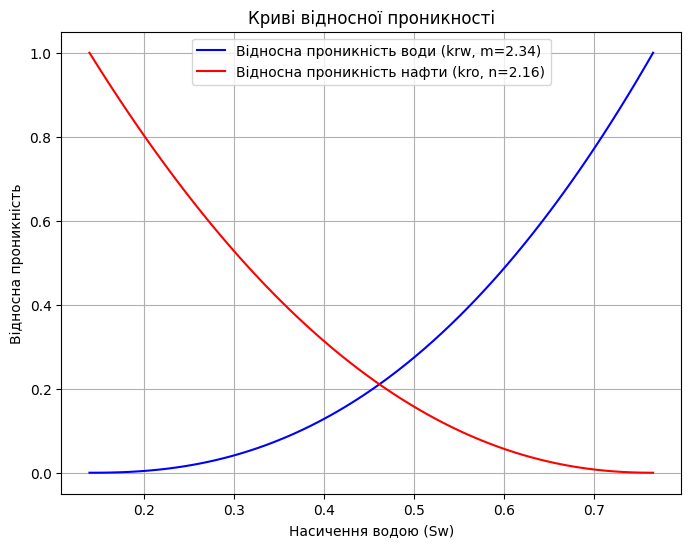

In [ ]:
# Step 5: Calculating and plotting relative permeability curves

# Define a range of water saturation values
S_w = np.linspace(Swi, 1 - Sor, 100)

# Calculate relative permeabilities using the Corey exponents
k_rw = krw(S_w, Swi, Sor, m_corey)
k_ro = kro(S_w, Swi, Sor, n_corey)

# Step 5 visualization: Plot the relative permeability curves
plt.figure(figsize=(8, 6))
plt.plot(S_w, k_rw, label=f"Відносна проникність води (krw, m={m_corey:.2f})", color='b')
plt.plot(S_w, k_ro, label=f"Відносна проникність нафти (kro, n={n_corey:.2f})", color='r')
plt.xlabel('Насичення водою (Sw)')
plt.ylabel('Відносна проникність')
plt.title('Криві відносної проникності')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:

# 🌊📊 Створення таблиці відносних проникностей

# 1. Визначення 10 рівномірно розподілених значень S_w для таблиці
num_points = 10
S_w_table_points = np.linspace(Swi, 1 - Sor, num_points)

# 2. Розрахунок k_rw та k_ro для цих 10 точок
k_rw_table = krw(S_w_table_points, Swi, Sor, m_corey)
k_ro_table = kro(S_w_table_points, Swi, Sor, n_corey)

# 3. Створення словника даних для DataFrame
table_data = {
    'S_w': S_w_table_points,
    'k_rw': k_rw_table,
    'k_ro': k_ro_table
}

# 4. Створення об'єкта DataFrame
df_rel_perm = pd.DataFrame(table_data)

# 5. Виведення таблиці, готової до копіювання

print("--- DataFrame відносних проникностей (10 точок) ---")

# Відображення DataFrame
# Використовуємо .to_string(), щоб гарантувати, що всі рядки будуть відображені,
# але оскільки їх лише 10, це не є суттєвим, тому просто виводимо df_rel_perm
# Встановлюємо опцію для відображення більшої кількості знаків після коми для точності
pd.set_option('display.float_format', '{:,.6f}'.format)

df_rel_perm.head(10)

--- DataFrame відносних проникностей (10 точок) ---


,S_w,k_rw,k_ro
0,0.139647,0.000000,1.000000
1,0.209165,0.005803,0.775702
2,0.278683,0.029453,0.581622
3,0.348201,0.076176,0.417135
4,0.417719,0.149494,0.281534
5,0.487236,0.252199,0.174002
6,0.556754,0.386645,0.093570
7,0.626272,0.554893,0.039031
8,0.695790,0.758785,0.008755
9,0.765308,1.000000,0.000000


#Step 6: Calculation of the Fractional Flow Curve (No Gravity)  (With Gravity)



We will calculate the fractional flow curve, considering the slope of the formation and the water movement, where the injection well is located lower than the production well. The calculation uses the previously calculated relative permeability curves.


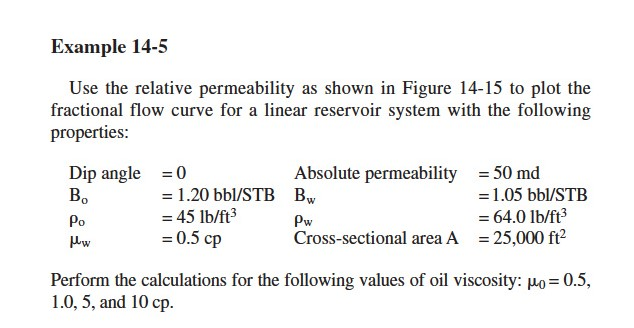

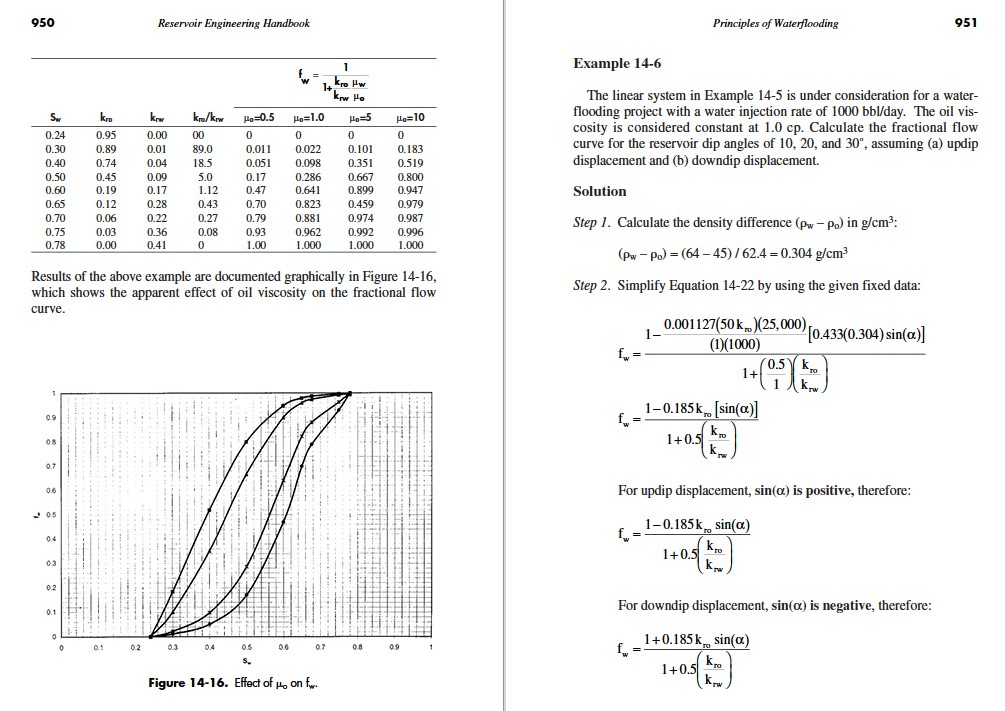

/tmp/ipykernel_22223/90238083.py:10: RuntimeWarning: divide by zero encountered in divide
  Y_2 = (k_ro * mu_w_cp) / (k_rw * mu_o_2_cp)


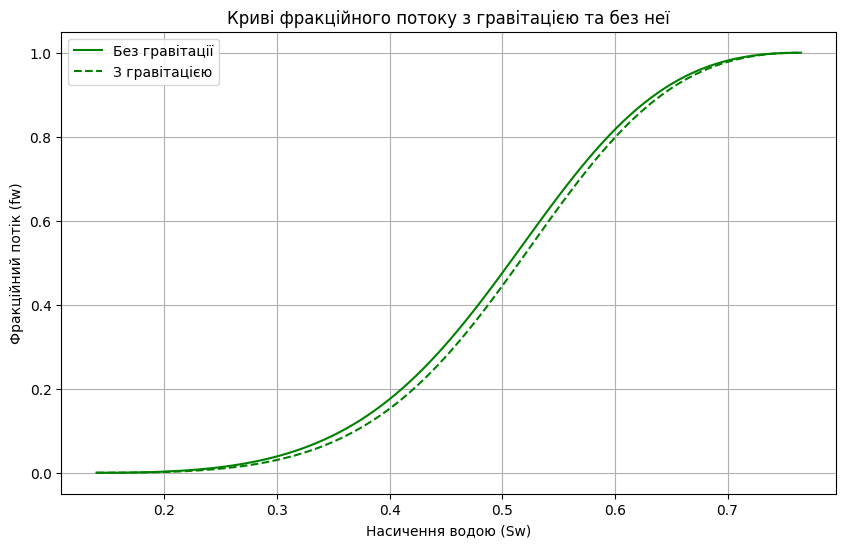

,Water Saturation (S_w),Fractional Flow (No Gravity - Viscosity 2),Fractional Flow (With Gravity - Viscosity 2)
0,0.139647,0.000000,0.000000
1,0.145967,0.000011,0.000007
2,0.152287,0.000058,0.000035
3,0.158607,0.000153,0.000094
4,0.164926,0.000308,0.000191
...,...,...,...
95,0.740029,0.997911,0.997503
96,0.746349,0.998903,0.998683
97,0.752668,0.999553,0.999461
98,0.758988,0.999902,0.999881


In [ ]:
# Step 6: Calculation of the fractional flow curve

# Correct fractional flow calculation with proper radian conversion
theta = np.radians(theta_deg_layer) # Convert dip angle to radians


# Fractional Flow with Gravity (for 2 viscosity)
# Step 1: Calculate X and Y terms
X_2 = (0.001127 * 0.433 * k_md * k_ro * A_ft2 * (rho_w_g_cm3 - rho_o_2_g_cm3)) / mu_o_2_cp
Y_2 = (k_ro * mu_w_cp) / (k_rw * mu_o_2_cp)
# Step 2: Calculate the fractional flow curves
fw_no_gravity_2 = 1 / (1 + Y_2)  # Fractional Flow without Gravity
# Fractional Flow with Gravity using the updated formula
fw_with_gravity_2 = (1 - (X_2 * np.sin(theta) / i_w_bbl_per_day)) / (1 + Y_2)



# Plotting the fractional flow curves
plt.figure(figsize=(10, 6))

# Plot fw_no_gravity curves for each viscosity

plt.plot(S_w, fw_no_gravity_2 * np.ones_like(S_w), label='Без гравітації', color='g')


# Plot fw_with_gravity curves for each viscosity

plt.plot(S_w, fw_with_gravity_2 * np.ones_like(S_w), 'g--', label='З гравітацією')


plt.xlabel('Насичення водою (Sw)')
plt.ylabel('Фракційний потік (fw)')
plt.title('Криві фракційного потоку з гравітацією та без неї')
plt.legend()
plt.grid(True)
plt.show()

# Step 4: Create a table of results
table_data = {
    'Water Saturation (S_w)': S_w,


    'Fractional Flow (No Gravity - Viscosity 2)': fw_no_gravity_2 * np.ones_like(S_w),
    'Fractional Flow (With Gravity - Viscosity 2)': fw_with_gravity_2 * np.ones_like(S_w),


}

df_table = pd.DataFrame(table_data)

# Display the first 100 rows of the corrected output table
df_table.head(100)  # Display first 10 rows of the table


## Step 7: Output Table with Saturation, Relative Permeabilities, and Fractional Flow (With Gravity)

We will generate a table with four columns: water saturation, water relative permeability, oil relative permeability, and fractional flow.


In [ ]:
# Step 7: Output table with corrected 4 columns (Sw, krw, kro, fw) matching the plotted data

# Ensure that water saturation values, relative permeabilities, and fractional flow values are recalculated in line with plotted data
output_data = {
    'Water Saturation (Sw)': S_w,            # Correct water saturation from Swi to 1 - Sor
    'Water Rel Perm (krw)': k_rw,            # Water relative permeability from Step 5
    'Oil Rel Perm (kro)': k_ro,              # Oil relative permeability from Step 5

    'Fractional Flow (No Gravity - Viscosity 2)': fw_no_gravity_2 * np.ones_like(S_w),


    'Fractional Flow (With Gravity - Viscosity 2)': fw_with_gravity_2 * np.ones_like(S_w),

}

# Create a pandas DataFrame for the corrected output table
df_output_corrected = pd.DataFrame(output_data)

# Display the first 100 rows of the corrected output table
df_output_corrected.head(100)


,Water Saturation (Sw),Water Rel Perm (krw),Oil Rel Perm (kro),Fractional Flow (No Gravity - Viscosity 2),Fractional Flow (With Gravity - Viscosity 2)
0,0.139647,0.000000,1.000000,0.000000,0.000000
1,0.145967,0.000021,0.978345,0.000011,0.000007
2,0.152287,0.000107,0.956945,0.000058,0.000035
3,0.158607,0.000276,0.935798,0.000153,0.000094
4,0.164926,0.000542,0.914904,0.000308,0.000191
...,...,...,...,...,...
95,0.740029,0.907867,0.000988,0.997911,0.997503
96,0.746349,0.930423,0.000531,0.998903,0.998683
97,0.752668,0.953296,0.000222,0.999553,0.999461
98,0.758988,0.976488,0.000050,0.999902,0.999881


# Step 8.1: Drawing the Tangent and Finding Breakthrough Point (No Gravity). For three viscosity cases.

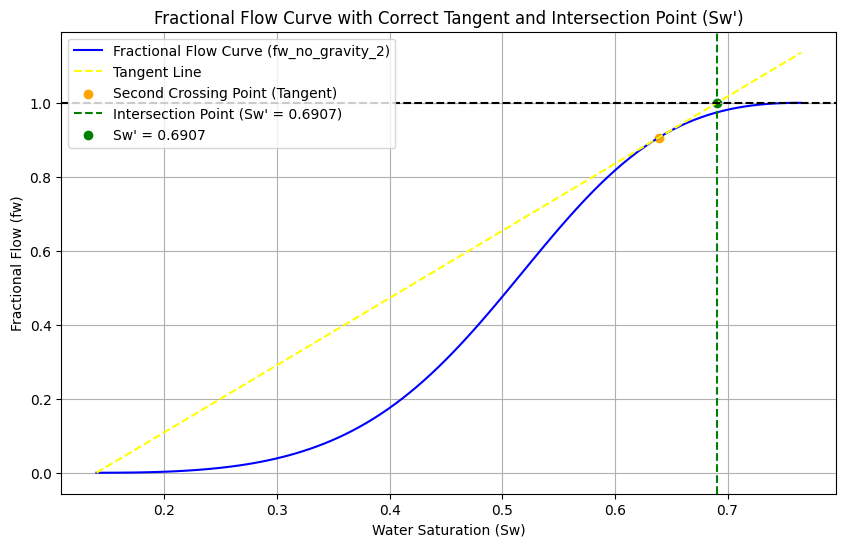

In [ ]:
# Step 8: Drawing the correct tangent to the fractional flow curve and finding Sw'


# First derivative (slope) of the fractional flow curve to help identify the tangent point
d_fw_d_Sw_2_ng = np.gradient(fw_no_gravity_2, S_w)
# Initialize breakthrough_idx_2
breakthrough_idx_2_ng = None
# Loop through the points of the curve to find the tangent point
for i in range(1, len(S_w)):
    slope_tangent_test_2_ng = (fw_no_gravity_2[i] - fw_no_gravity_2[0]) / (S_w[i] - S_w[0])
    fw_tangent_test_2_ng = slope_tangent_test_2_ng * (S_w - S_w[0]) + fw_no_gravity_2[0]
    # Allow for slight deviations and use a threshold to handle numerical inaccuracies
    tolerance_2_ng = 1e-5
    if np.all(fw_tangent_test_2_ng[:i] >= (fw_no_gravity_2[:i] - tolerance_2_ng)) and np.all(fw_tangent_test_2_ng[i:] >= (fw_no_gravity_2[i:] - tolerance_2_ng)):
        breakthrough_idx_2_ng = i
        break
# Check if we found a valid tangent
if breakthrough_idx_2_ng is None:
    raise ValueError("No valid tangent line found that satisfies the condition.")
# Calculate the slope of the tangent line
slope_tangent_2_ng = (fw_no_gravity_2[breakthrough_idx_2_ng] - fw_no_gravity_2[0]) / (S_w[breakthrough_idx_2_ng] - S_w[0])
# Equation of the tangent line
fw_tangent_2_ng = slope_tangent_2_ng * (S_w - S_w[0]) + fw_no_gravity_2[0]
# Extend the tangent line to find where y = 1 (Sw')
S_w_dash_2_ng = (1 - fw_no_gravity_2[0]) / slope_tangent_2_ng + S_w[0]

# Visualization: Plot the fractional flow curve and the tangent line
plt.figure(figsize=(10, 6))
plt.plot(S_w, fw_no_gravity_2, label='Fractional Flow Curve (fw_no_gravity_2)', color='b')
plt.plot(S_w, fw_tangent_2_ng, '--', label='Tangent Line', color='yellow')
plt.scatter(S_w[breakthrough_idx_2_ng], fw_no_gravity_2[breakthrough_idx_2_ng], color='orange', label='Second Crossing Point (Tangent)')
plt.axvline(x=S_w_dash_2_ng, color='green', linestyle='--', label=f'Intersection Point (Sw\' = {S_w_dash_2_ng:.4f})')
plt.scatter(S_w_dash_2_ng, 1, color='green', label=f'Sw\' = {S_w_dash_2_ng:.4f}')
plt.axhline(y=1, color='black', linestyle='--')
plt.xlabel('Water Saturation (Sw)')
plt.ylabel('Fractional Flow (fw)')
plt.title('Fractional Flow Curve with Correct Tangent and Intersection Point (Sw\')')
plt.legend()
plt.grid(True)
plt.show()





## Step 8.2: Drawing the Tangent and Finding Breakthrough Point (With Gravity). For three viscosity cases.



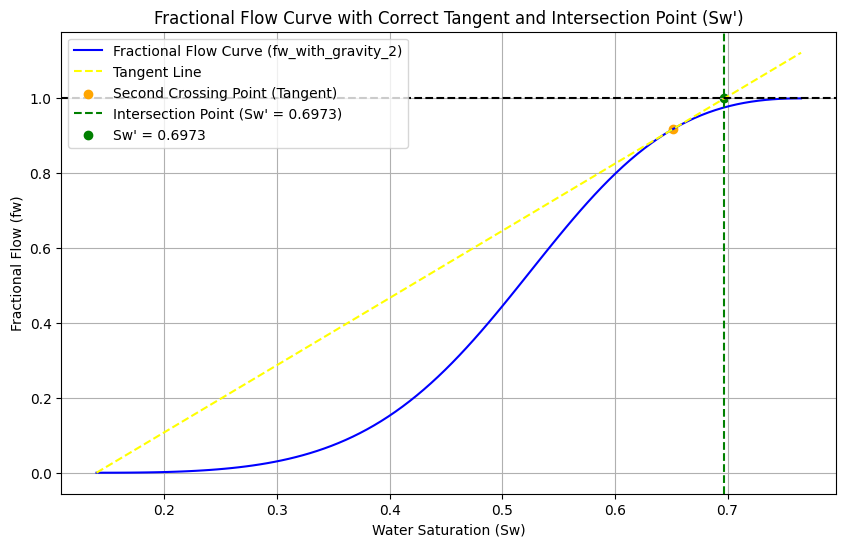

In [ ]:
# Step 8: Drawing the correct tangent to the fractional flow curve and finding Sw'



# First derivative (slope) of the fractional flow curve to help identify the tangent point
d_fw_d_Sw_2 = np.gradient(fw_with_gravity_2, S_w)
# Initialize breakthrough_idx_2
breakthrough_idx_2 = None
# Loop through the points of the curve to find the tangent point
for i in range(1, len(S_w)):
    slope_tangent_test_2 = (fw_with_gravity_2[i] - fw_with_gravity_2[0]) / (S_w[i] - S_w[0])
    fw_tangent_test_2 = slope_tangent_test_2 * (S_w - S_w[0]) + fw_with_gravity_2[0]
    # Allow for slight deviations and use a threshold to handle numerical inaccuracies
    tolerance_2 = 1e-5
    if np.all(fw_tangent_test_2[:i] >= (fw_with_gravity_2[:i] - tolerance_2)) and np.all(fw_tangent_test_2[i:] >= (fw_with_gravity_2[i:] - tolerance_2)):
        breakthrough_idx_2 = i
        break
# Check if we found a valid tangent
if breakthrough_idx_2 is None:
    raise ValueError("No valid tangent line found that satisfies the condition.")
# Calculate the slope of the tangent line
slope_tangent_2 = (fw_with_gravity_2[breakthrough_idx_2] - fw_with_gravity_2[0]) / (S_w[breakthrough_idx_2] - S_w[0])
# Equation of the tangent line
fw_tangent_2 = slope_tangent_2 * (S_w - S_w[0]) + fw_with_gravity_2[0]
# Extend the tangent line to find where y = 1 (Sw')
S_w_dash_2 = (1 - fw_with_gravity_2[0]) / slope_tangent_2 + S_w[0]

# Visualization: Plot the fractional flow curve and the tangent line
plt.figure(figsize=(10, 6))
plt.plot(S_w, fw_with_gravity_2, label='Fractional Flow Curve (fw_with_gravity_2)', color='b')
plt.plot(S_w, fw_tangent_2, '--', label='Tangent Line', color='yellow')
plt.scatter(S_w[breakthrough_idx_2], fw_with_gravity_2[breakthrough_idx_2], color='orange', label='Second Crossing Point (Tangent)')
plt.axvline(x=S_w_dash_2, color='green', linestyle='--', label=f'Intersection Point (Sw\' = {S_w_dash_2:.4f})')
plt.scatter(S_w_dash_2, 1, color='green', label=f'Sw\' = {S_w_dash_2:.4f}')
plt.axhline(y=1, color='black', linestyle='--')
plt.xlabel('Water Saturation (Sw)')
plt.ylabel('Fractional Flow (fw)')
plt.title('Fractional Flow Curve with Correct Tangent and Intersection Point (Sw\')')
plt.legend()
plt.grid(True)
plt.show()




#Step 9: Calculation of Oil Displacement Coefficient at the Breakthroughs (No Gravity) (With Gravity)
This remains the same, and you can use the previously provided code for Step 9 to calculate the recovery factor.

In [ ]:
# Step 9: Visualization of Breakthrough Water Saturation and Recovery Factor (RF)

# Formula 8: Ed_BT = (Sw_dash - Swi) / (1 - Swi)

Ed_BT_2_ng = (S_w_dash_2_ng - Swi) / (1 - Swi)

Ed_BT_2_wg = (S_w_dash_2 - Swi) / (1 - Swi)


# Step 9 visualization: Create a table to show the results, including the breakthrough point
rf_data = {
    'Viscosity Label': ['For Viscosity #2 (NO gravity)', 'For Viscosity #2 (WITH gravity)'],
    'Breakthrough Water Saturation (Sw_breakthrough)': [S_w[breakthrough_idx_2_ng], S_w[breakthrough_idx_2]],  # Add breakthrough Sw
    'Residual Water Saturation (Sw\' - Intersection)': [S_w_dash_2_ng, S_w_dash_2],
    'Oil Recovery Factor (Ed_BT)': [Ed_BT_2_ng, Ed_BT_2_wg]
}
df_rf = pd.DataFrame(rf_data)
# Display the results in a table
df_rf


,Viscosity Label,Breakthrough Water Saturation (Sw_breakthrough),Residual Water Saturation (Sw' - Intersection),Oil Recovery Factor (Ed_BT)
0,For Viscosity #2 (NO gravity),0.638912,0.690693,0.640488
1,For Viscosity #2 (WITH gravity),0.651551,0.697289,0.648155


#Step 10.1: Define and Visualize the Fractional Derivative (No Gravity). For three viscosity cases.

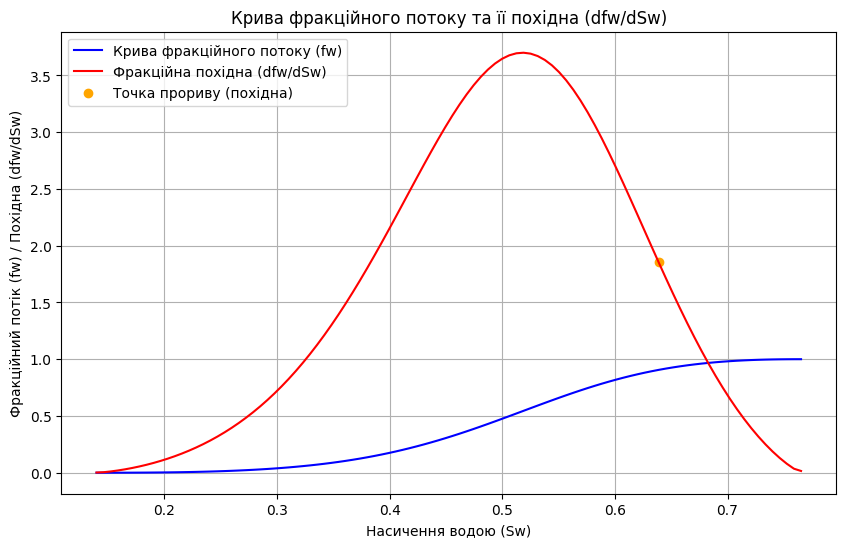

In [ ]:
# Step 10: Calculation and Visualization of the Fractional Derivative (dfw/dSw)

# Calculate the fractional derivative of the fractional flow curve with respect to Sw
  # Derivative of fw with respect to Sw
d_fw_d_Sw_2_ng = np.gradient(fw_no_gravity_2, S_w)


# Step 10 visualization: Plot the fractional flow curve and its derivative
plt.figure(figsize=(10, 6))
plt.plot(S_w, fw_no_gravity_2, label='Крива фракційного потоку (fw)', color='b')
plt.plot(S_w, d_fw_d_Sw_2_ng, label='Фракційна похідна (dfw/dSw)', color='r')
plt.scatter(S_w[breakthrough_idx_2_ng], d_fw_d_Sw_2_ng[breakthrough_idx_2_ng], color='orange', label='Точка прориву (похідна)')
plt.xlabel('Насичення водою (Sw)')
plt.ylabel('Фракційний потік (fw) / Похідна (dfw/dSw)')
plt.title('Крива фракційного потоку та її похідна (dfw/dSw)')
plt.legend()
plt.grid(True)
plt.show()




#Step 10.2: Define and Visualize the Fractional Derivative (With Gravity). For three viscosity cases.

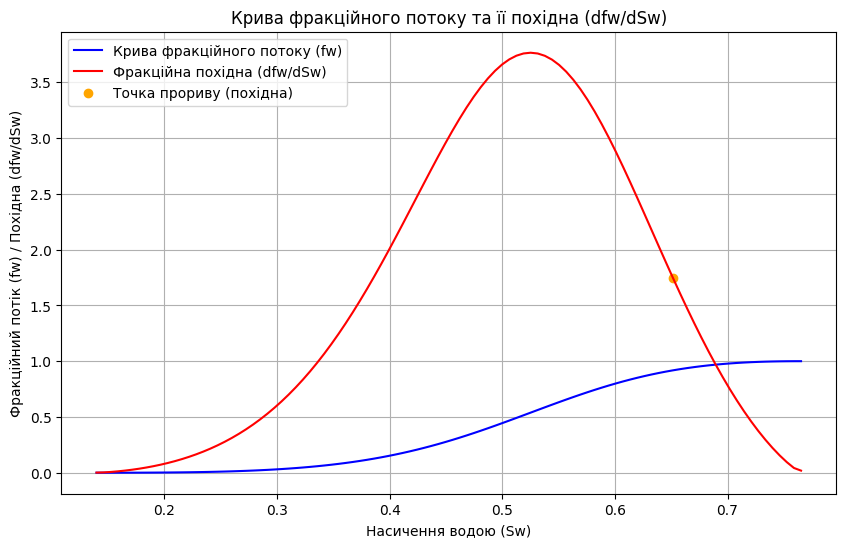

In [ ]:
# Step 10: Calculation and Visualization of the Fractional Derivative (dfw/dSw)

# Calculate the fractional derivative of the fractional flow curve with respect to Sw
  # Derivative of fw with respect to Sw
d_fw_d_Sw_2_wg = np.gradient(fw_with_gravity_2, S_w)




# Step 10 visualization: Plot the fractional flow curve and its derivative
plt.figure(figsize=(10, 6))
plt.plot(S_w, fw_with_gravity_2, label='Крива фракційного потоку (fw)', color='b')
plt.plot(S_w, d_fw_d_Sw_2_wg, label='Фракційна похідна (dfw/dSw)', color='r')
plt.scatter(S_w[breakthrough_idx_2], d_fw_d_Sw_2_wg[breakthrough_idx_2], color='orange', label='Точка прориву (похідна)')
plt.xlabel('Насичення водою (Sw)')
plt.ylabel('Фракційний потік (fw) / Похідна (dfw/dSw)')
plt.title('Крива фракційного потоку та її похідна (dfw/dSw)')
plt.legend()
plt.grid(True)
plt.show()




# Step 10.3 DataFrame

In [ ]:
# Assuming you have already calculated S_w, d_fw_d_Sw_1_wg, d_fw_d_Sw_2_wg, and d_fw_d_Sw_3_wg

# Create a DataFrame
df = pd.DataFrame({
    'Sw': S_w,

    'd_fw_d_Sw_2_ng': d_fw_d_Sw_2_ng,

    'd_fw_d_Sw_2_wg': d_fw_d_Sw_2_wg,

})

df = pd.DataFrame(df)
# Display the results in a table
df

,Sw,d_fw_d_Sw_2_ng,d_fw_d_Sw_2_wg
0,0.139647,0.001769,0.001053
1,0.145967,0.004591,0.002773
2,0.152287,0.011256,0.006912
3,0.158607,0.019775,0.012368
4,0.164926,0.029904,0.019046
...,...,...,...
95,0.740029,0.186952,0.221745
96,0.746349,0.129916,0.154951
97,0.752668,0.079065,0.094819
98,0.758988,0.035367,0.042622


#Step 11: Calculating the Tangent Differential at the Breakthrough Point (No / With  Gravity)

In [ ]:
# Step 11: Calculating the differential for the tangent (yellow line) at the breakthrough point

# The slope of the tangent line has already been calculated in step 8 as "slope_tangent"
# So, we just need to create a table that includes the water saturation at the breakthrough point
# and the corresponding constant value of the tangent differential (slope_tangent).

# The water saturation at the breakthrough point is S_w[breakthrough_idx]

Sw_breakthrough_2_ng = S_w[breakthrough_idx_2_ng]

Sw_breakthrough_2_wg = S_w[breakthrough_idx_2]


# Tangent differential (constant value) is simply the slope of the tangent line

tangent_differential_2_ng = slope_tangent_2_ng

tangent_differential_2_wg = slope_tangent_2


# Creating a table to show the breakthrough water saturation and the tangent differential
tangent_diff_data = {
    'Viscosity Label': ['For Viscosity #2 (NO gravity)', 'For Viscosity #2 (WITH gravity)'],
    'Water Saturation at Breakthrough (Sw)': [Sw_breakthrough_2_ng, Sw_breakthrough_2_wg],
    'Tangent Differential (df_tangent/dSw)': [tangent_differential_2_ng, tangent_differential_2_wg, ]
}

df_tangent_diff = pd.DataFrame(tangent_diff_data)

# Display the results in a table
df_tangent_diff

,Viscosity Label,Water Saturation at Breakthrough (Sw),Tangent Differential (df_tangent/dSw)
0,For Viscosity #2 (NO gravity),0.638912,1.814730
1,For Viscosity #2 (WITH gravity),0.651551,1.793265


# Step 12.1 (No gravity)

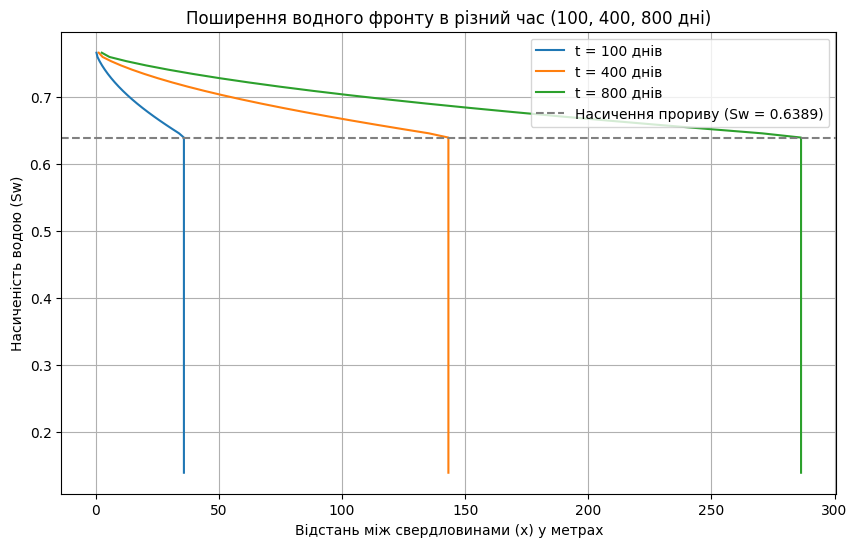

In [ ]:
# Step 12: Updated to calculate for water saturation points above the breakthrough point using d_fw_d_Sw

# Time values (in days)
times = [100, 400, 800]


# FOR VISCOSITY №2
# Calculate the distance of the water front for all saturation points below breakthrough (using tangent differential)
x_values_per_time_below_2_ng = []
for t in times:
    x_values_below_2_ng = []
    for Sw in S_w[:breakthrough_idx_2_ng+1]:  # Loop through water saturation points below breakthrough
        # Calculate the distance of the water front using the tangent differential
        x_ft_below_2_ng = (5.615 * i_w_bbl_per_day * t) / (phi * A_ft2) * tangent_differential_2_ng  # Distance in ft
        x_values_below_2_ng.append(x_ft_below_2_ng)
    # Convert to meters for plotting
    x_values_meters_below_2_ng = [x / 3.281 for x in x_values_below_2_ng]
    x_values_per_time_below_2_ng.append(x_values_meters_below_2_ng)

# Now calculate for saturation points above the breakthrough using d_fw_d_Sw_2 from Step 10
x_values_per_time_above_2_ng = []
for t in times:
    x_values_above_2_ng = []
    for i, Sw in enumerate(S_w[breakthrough_idx_2_ng+1:], start=breakthrough_idx_2_ng+1):  # Loop through water saturation points above breakthrough
        # Use d_fw_d_Sw for the corresponding saturation
        dfw_dSw_2_ng = d_fw_d_Sw_2_ng[i]  # Get the differential from Step 10
        # Calculate the distance of the water front using the formula
        x_ft_above_2_ng = (5.615 * i_w_bbl_per_day * t) / (phi * A_ft2) * dfw_dSw_2_ng  # Distance in ft
        x_values_above_2_ng.append(x_ft_above_2_ng)
    # Convert to meters for plotting
    x_values_meters_above_2_ng = [x / 3.281 for x in x_values_above_2_ng]
    x_values_per_time_above_2_ng.append(x_values_meters_above_2_ng)



# FOR VISCOSITY №2
# Plotting the results for all water saturation points (below and above breakthrough) as continuous lines
plt.figure(figsize=(10, 6))
# Combine the below and above breakthrough points for each time case into one continuous line
for i, t in enumerate(times):
    # Combine the x-values (below and above breakthrough) and S_w values
    x_combined_2_ng = np.concatenate((x_values_per_time_below_2_ng[i], x_values_per_time_above_2_ng[i]))
    S_w_combined_2_ng = np.concatenate((S_w[:breakthrough_idx_2_ng+1], S_w[breakthrough_idx_2_ng+1:]))
    # Plot the combined line for each time case
    plt.plot(x_combined_2_ng, S_w_combined_2_ng, label=f't = {t} днів')
# Marking the water breakthrough point (constant y-value at different x-values)
plt.axhline(y=Sw_breakthrough_2_ng, color='gray', linestyle='--', label=f'Насичення прориву (Sw = {Sw_breakthrough_2_ng:.4f})')
# Set labels and title (remove the columns of numbers from the bottom)
plt.xlabel('Відстань між свердловинами (x) у метрах')
plt.ylabel('Насиченість водою (Sw)')
plt.title('Поширення водного фронту в різний час (100, 400, 800 дні)')
plt.grid(True)
plt.legend()
plt.show()



# Step 12.2 (With gravity)

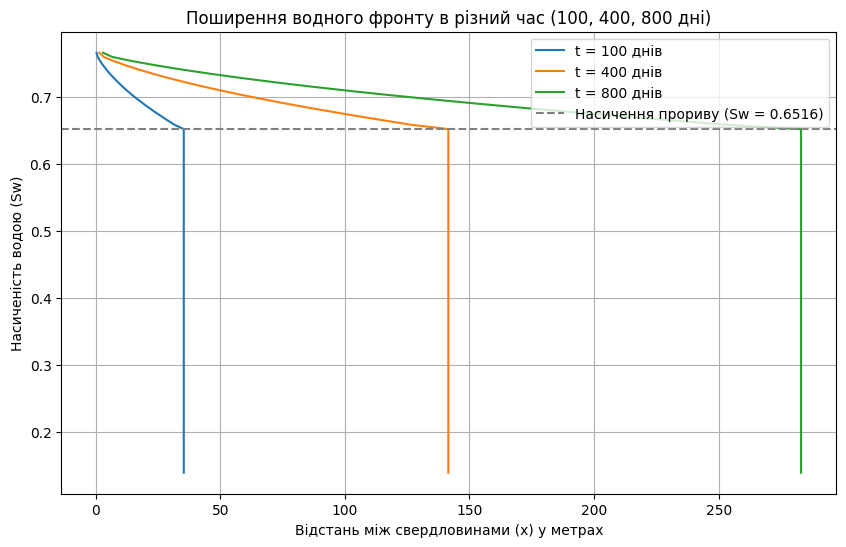

In [ ]:
# Step 12: Updated to calculate for water saturation points above the breakthrough point using d_fw_d_Sw

# Time values (in days)
times = [100, 400, 800]


# FOR VISCOSITY №2
# Calculate the distance of the water front for all saturation points below breakthrough (using tangent differential)
x_values_per_time_below_2_wg = []
for t in times:
    x_values_below_2_wg = []
    for Sw in S_w[:breakthrough_idx_2+1]:  # Loop through water saturation points below breakthrough
        # Calculate the distance of the water front using the tangent differential
        x_ft_below_2_wg = (5.615 * i_w_bbl_per_day * t) / (phi * A_ft2) * tangent_differential_2_wg  # Distance in ft
        x_values_below_2_wg.append(x_ft_below_2_wg)
    # Convert to meters for plotting
    x_values_meters_below_2_wg = [x / 3.281 for x in x_values_below_2_wg]
    x_values_per_time_below_2_wg.append(x_values_meters_below_2_wg)

# Now calculate for saturation points above the breakthrough using d_fw_d_Sw_2 from Step 10
x_values_per_time_above_2_wg = []
for t in times:
    x_values_above_2_wg = []
    for i, Sw in enumerate(S_w[breakthrough_idx_2+1:], start=breakthrough_idx_2+1):  # Loop through water saturation points above breakthrough
        # Use d_fw_d_Sw for the corresponding saturation
        dfw_dSw_2_wg = d_fw_d_Sw_2_wg[i]  # Get the differential from Step 10
        # Calculate the distance of the water front using the formula
        x_ft_above_2_wg = (5.615 * i_w_bbl_per_day * t) / (phi * A_ft2) * dfw_dSw_2_wg  # Distance in ft
        x_values_above_2_wg.append(x_ft_above_2_wg)
    # Convert to meters for plotting
    x_values_meters_above_2_wg = [x / 3.281 for x in x_values_above_2_wg]
    x_values_per_time_above_2_wg.append(x_values_meters_above_2_wg)



# FOR VISCOSITY №2
# Plotting the results for all water saturation points (below and above breakthrough) as continuous lines
plt.figure(figsize=(10, 6))
# Combine the below and above breakthrough points for each time case into one continuous line
for i, t in enumerate(times):
    # Combine the x-values (below and above breakthrough) and S_w values
    x_combined_2_wg = np.concatenate((x_values_per_time_below_2_wg[i], x_values_per_time_above_2_wg[i]))
    S_w_combined_2_wg = np.concatenate((S_w[:breakthrough_idx_2+1], S_w[breakthrough_idx_2+1:]))
    # Plot the combined line for each time case
    plt.plot(x_combined_2_wg, S_w_combined_2_wg, label=f't = {t} днів')
# Marking the water breakthrough point (constant y-value at different x-values)
plt.axhline(y=Sw_breakthrough_2_wg, color='gray', linestyle='--', label=f'Насичення прориву (Sw = {Sw_breakthrough_2_wg:.4f})')
# Set labels and title (remove the columns of numbers from the bottom)
plt.xlabel('Відстань між свердловинами (x) у метрах')
plt.ylabel('Насиченість водою (Sw)')
plt.title('Поширення водного фронту в різний час (100, 400, 800 дні)')
plt.grid(True)
plt.legend()
plt.show()



# Step 14.1: Output a table (NO GRAVITY) with Water Saturation and corresponding distances (m) for 3 different time cases (100, 400, 800 days), for 3 different viscosity cases

In [ ]:
# Create a DataFrame with water saturation and the distances for each time case
distance_data_1 = {


    'VISCOSITY №2 Dist(m) (t=100d)': np.concatenate((x_values_per_time_below_2_ng[0], x_values_per_time_above_2_ng[0])),  # Combine distances for t = 100 days
    'VISCOSITY №2 Dist(m) (t=400d)': np.concatenate((x_values_per_time_below_2_ng[1], x_values_per_time_above_2_ng[1])),  # Combine distances for t = 400 days
    'VISCOSITY №2 Dist(m) (t=800d)': np.concatenate((x_values_per_time_below_2_ng[2], x_values_per_time_above_2_ng[2])),  # Combine distances for t = 800 days

}
# Create a pandas DataFrame
df_distance_1 = pd.DataFrame(distance_data_1)
# Display the table
df_distance_1.head(100)  # Display the first 100 rows


,VISCOSITY №2 Dist(m) (t=100d),VISCOSITY №2 Dist(m) (t=400d),VISCOSITY №2 Dist(m) (t=800d)
0,35.800855,143.203420,286.406841
1,35.800855,143.203420,286.406841
2,35.800855,143.203420,286.406841
3,35.800855,143.203420,286.406841
4,35.800855,143.203420,286.406841
...,...,...,...
95,3.688170,14.752680,29.505360
96,2.562967,10.251867,20.503734
97,1.559787,6.239147,12.478295
98,0.697711,2.790845,5.581690


# Step 14.2: Output a table (WITH GRAVITY) with Water Saturation and corresponding distances (m) for 3 different time cases (100, 400, 800 days), for 3 different viscosity cases

In [ ]:
# Create a DataFrame with water saturation and the distances for each time case
distance_data_1 = {


    'VISCOSITY №2 Dist(m) (t=100d)': np.concatenate((x_values_per_time_below_2_wg[0], x_values_per_time_above_2_wg[0])),  # Combine distances for t = 100 days
    'VISCOSITY №2 Dist(m) (t=400d)': np.concatenate((x_values_per_time_below_2_wg[1], x_values_per_time_above_2_wg[1])),  # Combine distances for t = 400 days
    'VISCOSITY №2 Dist(m) (t=800d)': np.concatenate((x_values_per_time_below_2_wg[2], x_values_per_time_above_2_wg[2])),  # Combine distances for t = 800 days


}
# Create a pandas DataFrame
df_distance_1 = pd.DataFrame(distance_data_1)
# Display the table
df_distance_1.head(100)  # Display the first 100 rows


,VISCOSITY №2 Dist(m) (t=100d),VISCOSITY №2 Dist(m) (t=400d),VISCOSITY №2 Dist(m) (t=800d)
0,35.377379,141.509515,283.019029
1,35.377379,141.509515,283.019029
2,35.377379,141.509515,283.019029
3,35.377379,141.509515,283.019029
4,35.377379,141.509515,283.019029
...,...,...,...
95,4.374558,17.498233,34.996466
96,3.056865,12.227461,24.454922
97,1.870573,7.482293,14.964587
98,0.840842,3.363367,6.726733


#Step 15. All parametres at the Breakthrough (tBT) with and without gravity, 3 viscosity
---



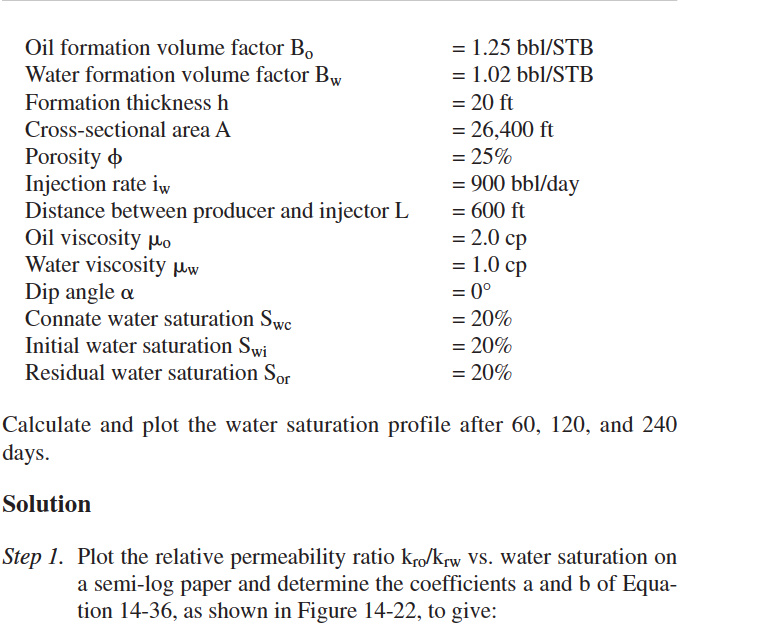

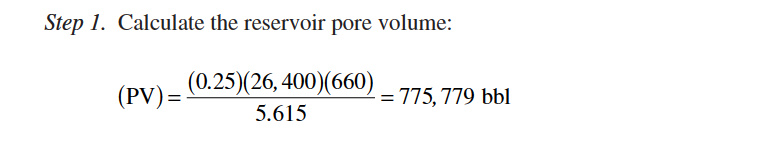

In [ ]:
# Step 15: Calculate Pore Volume (PV)
PV_bbl = (phi * A_ft2 * L_ft) / 5.615  # Pore volume in bbl
PV_m3 = PV_bbl * conversion_factor_bbl_to_m3  # Convert PV to m³
Ns_STB = 7758 * A_acre * L_ft * phi * (1 - Swi) / Bo  # initial oil in place in STB

# cumulative oil production at Breakthrough , STB

Np_BT_STB_2_ng = Ns_STB * Ed_BT_2_ng

Np_BT_STB_2_wg = Ns_STB * Ed_BT_2_wg


#  Calculate Time to Breakthrough (tBT), days

tBT_days_2_ng = PV_bbl / (i_w_bbl_per_day * tangent_differential_2_ng)

tBT_days_2_wg = PV_bbl / (i_w_bbl_per_day * tangent_differential_2_wg)


#  Calculate Cumulative Water Injected at Breakthrough (WiBT), bbl

WiBT_bbl_2_ng = i_w_bbl_per_day * tBT_days_2_ng

WiBT_bbl_2_wg = i_w_bbl_per_day * tBT_days_2_wg


 # Convert WiBT to m³
WiBT_m3_2_ng = WiBT_bbl_2_ng * conversion_factor_bbl_to_m3
 # Convert WiBT to m³
WiBT_m3_2_wg = WiBT_bbl_2_wg * conversion_factor_bbl_to_m3



# Calculate Cumulative Pore Volumes of Water Injected at Breakthrough (QiBT)

QiBT_2_ng = 1 / tangent_differential_2_ng

QiBT_2_wg = 1 / tangent_differential_2_wg


# Calculate WORs exactly at breakthrough by applying Equation

WORs_BT_2_ng = Bo / (Bw * (1 / fw_no_gravity_2[breakthrough_idx_2_ng] - 1))

WORs_BT_2_wg = Bo / (Bw * (1 / fw_with_gravity_2[breakthrough_idx_2] - 1))

# Output results in a table format
# Словник з даними, де залишено тільки загальні параметри та Випадок №2
results_data = {
    "Parameter": [
        "Pore Volume (PV)",
        "Ns_STB",
        "Cumulative oil production at Breakthrough (NO gravity) №2 (NpBT_2)",
        "Cumulative oil production at Breakthrough (WITH gravity) №2 (NpBT_2)",
        "Time to Breakthrough (NO gravity) №2 (tBT_2)",
        "Time to Breakthrough (WITH gravity) №2 (tBT_2)",
        "Cumulative Water Injected at Breakthrough (NO gravity) №2 (WiBT_2)",
        "Cumulative Water Injected at Breakthrough (WITH gravity) №2 (WiBT_2)",
        "Cumulative Pore Volumes at Breakthrough (NO gravity) №2 (QiBT_2)",
        "Cumulative Pore Volumes at Breakthrough (WITH gravity) №2 (QiBT_2)",
        "WORs_BT_2_ng",
        "WORs_BT_2_wg"
    ],
    "Value (bbl)": [
        PV_bbl,
        Ns_STB,
        Np_BT_STB_2_ng,
        Np_BT_STB_2_wg,
        tBT_days_2_ng,
        tBT_days_2_wg,
        WiBT_bbl_2_ng,
        WiBT_bbl_2_wg,
        QiBT_2_ng,
        QiBT_2_wg,
        WORs_BT_2_ng,
        WORs_BT_2_wg
    ],
    "Value (m³)": [
        PV_m3,
        None,
        None,
        None,
        None,
        None,
        WiBT_m3_2_ng,
        WiBT_m3_2_wg,
        None,
        None,
        None,
        None
    ],
    "Units": [
        "bbl/m³",
        "STB",
        "STB",
        "STB",
        "days",
        "days",
        "bbl/m³",
        "bbl/m³",
        "pore volumes",
        "pore volumes",
        "STB/STB",
        "STB/STB"
    ]
}

# Створення DataFrame
df_results = pd.DataFrame(results_data)

# Відображення результатів
df_results

,Parameter,Value (bbl),Value (m³),Units
0,Pore Volume (PV),"3,656,732.629823","581,372.950618",bbl/m³
1,Ns_STB,"2,108,691.906630",NaN,STB
2,Cumulative oil production at Breakthrough (NO ...,"1,350,592.638316",NaN,STB
3,Cumulative oil production at Breakthrough (WIT...,"1,366,759.582233",NaN,STB
4,Time to Breakthrough (NO gravity) №2 (tBT_2),"3,203.638796",NaN,days
5,Time to Breakthrough (WITH gravity) №2 (tBT_2),"3,241.987182",NaN,days
6,Cumulative Water Injected at Breakthrough (NO ...,"2,015,027.933303","320,363.246032",bbl/m³
7,Cumulative Water Injected at Breakthrough (WIT...,"2,039,148.339903","324,198.077116",bbl/m³
8,Cumulative Pore Volumes at Breakthrough (NO gr...,0.551046,NaN,pore volumes
9,Cumulative Pore Volumes at Breakthrough (WITH ...,0.557642,NaN,pore volumes


# Verefication Np

In [ ]:

Np_BT_STB_2_ng_v = WiBT_bbl_2_ng / Bo

Np_BT_STB_2_wg_v = WiBT_bbl_2_wg / Bo


# Creating a table to show the breakthrough water saturation and the tangent differential
tangent_diff_data = {
    'Label': ['For Viscosity #2 (NO gravity)', 'For Viscosity #2 (WITH gravity)'],
    'Water Saturation at Breakthrough (Sw)': [Np_BT_STB_2_ng_v, Np_BT_STB_2_wg_v]
}

df_tangent_diff = pd.DataFrame(tangent_diff_data)

# Display the results in a table
df_tangent_diff

,Label,Water Saturation at Breakthrough (Sw)
0,For Viscosity #2 (NO gravity),"1,350,554.915082"
1,For Viscosity #2 (WITH gravity),"1,366,721.407442"


#16 Verification All parametres at the Breakthrough (tBT) for gravity, viscosity 1
 (with grawity) vscosity #1 (where S_w_dash_1 from step 8.2 )

In [ ]:
# Step 16: Calculating the highlighted formulas. FOR VISCOSITY №1

# Using derived values from previous steps
# Assuming 'df_tangent_dSw' is the tangent slope (tangent_differential)

# Cumulative water injected at breakthrough
WiBT_formula1 = PV_bbl * QiBT_2_wg  # Based on first formula WiBT1 = (PV) * QiBT

# Alternative calculation of WiBT using the slope
WiBT_formula2 = PV_bbl * (1 / tangent_differential_2_wg)

# Average water saturation at breakthrough (alternative formula if needed)
WiBT_formula3 = PV_bbl * (S_w_dash_2 - Swi)  # Based on WiBT3 = (PV)(S_w* - Swi)

df_tangent_dSw_2 = (1-0) / (S_w_dash_2 - Swi)

# Output the results in a table format
result_data_formula = {
    "Parameter": [
        "Cumulative Water Injected at Breakthrough (WiBT) - Formula 1",
        "Cumulative Water Injected at Breakthrough (WiBT) - Formula 2",
        "Cumulative Water Injected at Breakthrough (WiBT) - Formula 3",
        "Tangent Slope (dfw/dSw) at Swf",
        "Tangent Slope_2 formula"
    ],
    "Value": [WiBT_formula1, WiBT_formula2, WiBT_formula3, tangent_differential_2_wg, df_tangent_dSw_2],
    "Units": ["bbl", "bbl", "bbl", "dimensionless", "dimensionless"]
}

# Create DataFrame
df_results_formula = pd.DataFrame(result_data_formula)

# Display the results
df_results_formula

,Parameter,Value,Units
0,Cumulative Water Injected at Breakthrough (WiB...,"2,039,148.339903",bbl
1,Cumulative Water Injected at Breakthrough (WiB...,"2,039,148.339903",bbl
2,Cumulative Water Injected at Breakthrough (WiB...,"2,039,148.339903",bbl
3,Tangent Slope (dfw/dSw) at Swf,1.793265,dimensionless
4,Tangent Slope_2 formula,1.793265,dimensionless


# Step 17. Recovery performance after breakthrough with and without gravity, 3 viscosity

In [ ]:
# Find the index of "Second Crossing Point (Tangent)" and the corresponding values


start_idx_2_ng = breakthrough_idx_2_ng
Sw_values_2_ng = S_w[start_idx_2_ng:]  # Sw starting from Second Crossing Point inclusive
fw_values_2_ng = fw_no_gravity_2[start_idx_2_ng:]  # Corresponding fw
dfw_dSw_values_2_ng = d_fw_d_Sw_2_ng[start_idx_2_ng:]  # Corresponding derivatives
Sw_dash_values_2_ng = Sw_values_2_ng + (1 - fw_values_2_ng) / dfw_dSw_values_2_ng # Calculate Sw_dash
Qi_2_ng = 1 / dfw_dSw_values_2_ng
Winj_2_ng = PV_bbl * Qi_2_ng
t_2_ng = Winj_2_ng / i_w_bbl_per_day
Ed_2_ng = (Sw_dash_values_2_ng - Swi) / (1 - Swi)
Np_2_ng = Ns_STB * Ed_2_ng
Wp_2_ng = (Winj_2_ng - (Sw_dash_values_2_ng - Swi) * PV_bbl) / Bw
WORs_2_ng = Bo / (Bw * (1 / fw_values_2_ng - 1))
Qo_2_ng = i_w_bbl_per_day / (Bo + Bw * WORs_2_ng)
Qw_2_ng = Qo_2_ng * WORs_2_ng

start_idx_2_wg = breakthrough_idx_2
Sw_values_2_wg = S_w[start_idx_2_wg:]  # Sw starting from Second Crossing Point inclusive
fw_values_2_wg = fw_with_gravity_2[start_idx_2_wg:]  # Corresponding fw
dfw_dSw_values_2_wg = d_fw_d_Sw_2_wg[start_idx_2_wg:]  # Corresponding derivatives
Sw_dash_values_2_wg = Sw_values_2_wg + (1 - fw_values_2_wg) / dfw_dSw_values_2_wg # Calculate Sw_dash
Qi_2_wg = 1 / dfw_dSw_values_2_wg
Winj_2_wg = PV_bbl * Qi_2_wg
t_2_wg = Winj_2_wg / i_w_bbl_per_day
Ed_2_wg = (Sw_dash_values_2_wg - Swi) / (1 - Swi)
Np_2_wg = Ns_STB * Ed_2_wg
Wp_2_wg = (Winj_2_wg - (Sw_dash_values_2_wg - Swi) * PV_bbl) / Bw
WORs_2_wg = Bo / (Bw * (1 / fw_values_2_wg - 1))
Qo_2_wg = i_w_bbl_per_day / (Bo + Bw * WORs_2_wg)
Qw_2_wg = Qo_2_wg * WORs_2_wg


# Create the two DataFrames as before

table_data_2_ng = pd.DataFrame({
    'Sw (2ng)': Sw_values_2_ng,
    'fw (2ng)': fw_values_2_ng,
    'd_fw_d_Sw (2ng)': dfw_dSw_values_2_ng,
    'Sw_dash (2ng)': Sw_dash_values_2_ng,
    'Qi (2ng) ?': Qi_2_ng,
    'Winj (2ng) (bbl)': Winj_2_ng,
    't (2ng) (days)': t_2_ng,
    'Ed (2ng) none': Ed_2_ng,
    'Np (2ng) STB': Np_2_ng,
    'Wp (2ng) STB': Wp_2_ng,
    'WORs (2ng) STB/STB': WORs_2_ng,
    'Qo (2ng) STB/day': Qo_2_ng,
    'Qw (2ng) STB/day': Qw_2_ng
})


table_data_2_wg = pd.DataFrame({
    'Sw (2wg)': Sw_values_2_wg,
    'fw (2wg)': fw_values_2_wg,
    'd_fw_d_Sw (2wg)': dfw_dSw_values_2_wg,
    'Sw_dash (2wg)': Sw_dash_values_2_wg,
    'Qi (2wg) ?': Qi_2_wg,
    'Winj (2wg) (bbl)': Winj_2_wg,
    't (2wg) (days)': t_2_wg,
    'Ed (2wg) none': Ed_2_wg,
    'Np (2wg) STB': Np_2_wg,
    'Wp (2wg) STB': Wp_2_wg,
    'WORs (2wg) STB/STB': WORs_2_wg,
    'Qo (2wg) STB/day': Qo_2_wg,
    'Qw (2wg) STB/day': Qw_2_wg
})


# Concatenate the DataFrames horizontally
combined_table = pd.concat([table_data_2_ng, table_data_2_wg,], axis=1)
# Display the combined DataFrame
combined_table



/tmp/ipykernel_22223/642284458.py:15: RuntimeWarning: divide by zero encountered in divide
  WORs_2_ng = Bo / (Bw * (1 / fw_values_2_ng - 1))
/tmp/ipykernel_22223/642284458.py:17: RuntimeWarning: invalid value encountered in multiply
  Qw_2_ng = Qo_2_ng * WORs_2_ng
/tmp/ipykernel_22223/642284458.py:30: RuntimeWarning: divide by zero encountered in divide
  WORs_2_wg = Bo / (Bw * (1 / fw_values_2_wg - 1))
/tmp/ipykernel_22223/642284458.py:32: RuntimeWarning: invalid value encountered in multiply
  Qw_2_wg = Qo_2_wg * WORs_2_wg


,Sw (2ng),fw (2ng),d_fw_d_Sw (2ng),Sw_dash (2ng),Qi (2ng) ?,Winj (2ng) (bbl),t (2ng) (days),Ed (2ng) none,Np (2ng) STB,Wp (2ng) STB,WORs (2ng) STB/STB,Qo (2ng) STB/day,Qw (2ng) STB/day,Sw (2wg),fw (2wg),d_fw_d_Sw (2wg),Sw_dash (2wg),Qi (2wg) ?,Winj (2wg) (bbl),t (2wg) (days),Ed (2wg) none,Np (2wg) STB,Wp (2wg) STB,WORs (2wg) STB/STB,Qo (2wg) STB/day,Qw (2wg) STB/day
0,0.638912,0.906031,1.852488,0.689638,0.539814,"1,973,957.131633","3,138.341431",0.639262,"1,348,005.847457","-36,481.781870",14.103498,39.614441,558.702210,0.651551,0.917980,1.746647,0.698510,0.572526,"2,093,573.378598","3,328.516090",0.649574,"1,369,751.584347","48,981.466888",16.371257,34.577098,566.070558
1,0.645232,0.917299,1.714462,0.693469,0.583273,"2,132,874.907822","3,391.000536",0.643715,"1,357,396.668128","105,583.966258",16.224320,34.864350,565.650382,0.657871,0.928575,1.607653,0.702300,0.622025,"2,274,577.907462","3,616.290329",0.653979,"1,379,039.426432","212,851.521324",19.016657,30.110646,572.603839
2,0.651551,0.927701,1.579048,0.697338,0.633293,"2,315,783.664093","3,681.802255",0.648212,"1,366,878.664519","271,036.919982",18.769165,30.478983,572.065056,0.664191,0.938300,1.471774,0.706113,0.679452,"2,484,574.007647","3,950.157489",0.658411,"1,388,386.643780","405,057.836449",22.244670,26.010767,578.600918
3,0.657871,0.937257,1.446907,0.701235,0.691130,"2,527,275.845119","4,018.047994",0.652741,"1,376,429.661150","464,411.912208",21.850590,26.450442,577.957784,0.670511,0.947177,1.339584,0.709943,0.746500,"2,729,752.312342","4,339.959891",0.662863,"1,397,773.158337","631,699.028742",26.228947,22.268341,584.075133
4,0.664191,0.945989,1.318614,0.705151,0.758372,"2,773,164.819371","4,408.980270",0.657293,"1,386,028.836506","691,438.779507",25.619826,22.769184,583.342527,0.676831,0.955232,1.211573,0.713781,0.825373,"3,018,168.704034","4,798.505367",0.667324,"1,407,180.280364","900,700.359770",31.211100,18.872833,589.041895
5,0.670511,0.953924,1.194656,0.709079,0.837061,"3,060,907.762032","4,866.455047",0.661859,"1,395,656.634338","959,457.082953",30.283553,19.424250,588.235313,0.683151,0.962491,1.088155,0.717621,0.918987,"3,360,489.152802","5,342.751455",0.671786,"1,416,590.626833","1,222,544.089174",37.534738,15.812509,593.518369
6,0.676831,0.961089,1.075441,0.713012,0.929851,"3,400,215.972151","5,405.912058",0.666430,"1,405,294.681881","1,278,014.577883",36.129736,16.403494,592.653909,0.689470,0.968986,0.969668,0.721455,1.031281,"3,771,119.432367","5,995.601508",0.676243,"1,425,988.046419","1,611,377.149135",45.700952,13.074633,597.523184
7,0.683151,0.967517,0.961297,0.716941,1.040261,"3,803,956.467517","6,047.808229",0.670997,"1,414,925.714231","1,659,751.241072",43.568460,13.693794,596.617510,0.695790,0.974748,0.856383,0.725277,1.167701,"4,269,971.680183","6,788.713300",0.680686,"1,435,357.549871","2,086,743.167880",56.462063,10.645664,601.076146
8,0.689470,0.973240,0.852481,0.720861,1.173047,"4,289,519.696535","6,819.792166",0.675553,"1,424,533.504035","2,121,740.267557",53.198571,11.281251,600.146444,0.702110,0.979810,0.748513,0.729083,1.335981,"4,885,326.493384","7,767.049392",0.685110,"1,444,685.244131","2,676,388.542465",70.986742,8.511420,604.198001
9,0.695790,0.978292,0.749183,0.724766,1.334787,"4,880,958.619879","7,760.105027",0.680091,"1,434,102.795504","2,687,585.306038",65.920348,9.151376,603.261908,0.708430,0.984208,0.646218,0.732867,1.547465,"5,658,667.473563","8,996.563447",0.689507,"1,453,958.267733","3,421,002.283052",91.165540,6.657233,606.910205


# Step 18. Recovery performance before breakthrough with and without gravity, 3 viscosity

In [ ]:
# Find the minimum value of t_1_ng

min_t_2_ng = np.min(t_2_ng)
if min_t_2_ng < tBT_days_2_ng:
    tBT_days_2_ng = min_t_2_ng - 1

time_points_2_ng = np.linspace(0, tBT_days_2_ng, 5)
Winj_before_2_ng = i_w_bbl_per_day * time_points_2_ng
Qo_before_2_ng = i_w_bbl_per_day / Bo
WORs_before_2_ng = 0
Wp_before_2_ng = 0
Np_before_2_ng = Winj_before_2_ng / Bo
Qi_before_2_ng = Winj_before_2_ng / PV_bbl
Ed_before_2_ng = Np_before_2_ng / Ns_STB
Qw_before_2_ng = 0


min_t_2_wg = np.min(t_2_wg)
if min_t_2_wg < tBT_days_2_wg:
    tBT_days_2_wg = min_t_2_wg - 1

time_points_2_wg = np.linspace(0, tBT_days_2_wg, 5)
Winj_before_2_wg = i_w_bbl_per_day * time_points_2_wg
Qo_before_2_wg = i_w_bbl_per_day / Bo
WORs_before_2_wg = 0
Wp_before_2_wg = 0
Np_before_2_wg = Winj_before_2_wg / Bo
Qi_before_2_wg = Winj_before_2_wg / PV_bbl
Ed_before_2_wg = Np_before_2_wg / Ns_STB
Qw_before_2_wg = 0



table_data_before_2_ng = pd.DataFrame({'Days': time_points_2_ng,
        'Winj_before_2_ng': Winj_before_2_ng,
        'Qo_before_2_ng': Qo_before_2_ng,
        'WORs_before_2_ng': WORs_before_2_ng,
        'Wp_before_2_ng': Wp_before_2_ng,
        'Np_before_2_ng': Np_before_2_ng,
        'Qi_before_2_ng': Qi_before_2_ng,
        'Ed_before_2_ng': Ed_before_2_ng,
        'Qw_before_2_ng': Qw_before_2_ng
})


table_data_before_2_wg = pd.DataFrame({'Days': time_points_2_wg,
        'Winj_before_2_wg': Winj_before_2_wg,
        'Qo_before_2_wg': Qo_before_2_wg,
        'WORs_before_2_wg': WORs_before_2_wg,
        'Wp_before_2_wg': Wp_before_2_wg,
        'Np_before_2_wg': Np_before_2_wg,
        'Qi_before_2_wg': Qi_before_2_wg,
        'Ed_before_2_wg': Ed_before_2_wg,
        'Qw_before_2_wg': Qw_before_2_wg
})

# Concatenate the DataFrames horizontally
combined_table_2 = pd.concat([table_data_before_2_ng, table_data_before_2_wg], axis=1)
# Display the combined DataFrame
combined_table_2


,Days,Winj_before_2_ng,Qo_before_2_ng,WORs_before_2_ng,Wp_before_2_ng,Np_before_2_ng,Qi_before_2_ng,Ed_before_2_ng,Qw_before_2_ng,Days,Winj_before_2_wg,Qo_before_2_wg,WORs_before_2_wg,Wp_before_2_wg,Np_before_2_wg,Qi_before_2_wg,Ed_before_2_wg,Qw_before_2_wg
0,0.000000,0.000000,421.569035,0,0,0.000000,0.000000,0.000000,0,0.000000,0.000000,421.569035,0,0,0.000000,0.000000,0.000000,0
1,784.335358,"493,332.037658",421.569035,0,0,"330,651.499771",0.134911,0.156804,0,810.496796,"509,787.084976",421.569035,0,0,"341,680.351861",0.139411,0.162034,0
2,"1,568.670716","986,664.075316",421.569035,0,0,"661,302.999542",0.269821,0.313608,0,"1,620.993591","1,019,574.169952",421.569035,0,0,"683,360.703721",0.278821,0.324069,0
3,"2,353.006073","1,479,996.112974",421.569035,0,0,"991,954.499313",0.404732,0.470412,0,"2,431.490387","1,529,361.254928",421.569035,0,0,"1,025,041.055582",0.418232,0.486103,0
4,"3,137.341431","1,973,328.150633",421.569035,0,0,"1,322,605.999084",0.539642,0.627216,0,"3,241.987182","2,039,148.339903",421.569035,0,0,"1,366,721.407442",0.557642,0.648137,0


# Step 19.1 Combined general table for 3 *viscosity* (NO GRAVITY)

In [ ]:
# Create DataFrames for before and after breakthrough


df_before_2_ng = pd.DataFrame({
    'Time (2ng) (days)': time_points_2_ng,
    'Qi (2ng) (none)': Qi_before_2_ng,
    'Ed (2ng) (none)': Ed_before_2_ng,
    'Np (2ng) (STB)': Np_before_2_ng,
    'Winj (2ng) (bbl)': Winj_before_2_ng,
    'Wp (2ng) (STB)': Wp_before_2_ng,
    'WORs (2ng) (STB/STB)': WORs_before_2_ng,
    'Qo (2ng) (STB/day)': Qo_before_2_ng,
    'Qw (2ng) (STB/day)': Qw_before_2_ng
})
df_after_2_ng = pd.DataFrame({
    'Time (2ng) (days)': t_2_ng,
    'Qi (2ng) (none)': Qi_2_ng,
    'Ed (2ng) (none)': Ed_2_ng,
    'Np (2ng) (STB)': Np_2_ng,
    'Winj (2ng) (bbl)': Winj_2_ng,
    'Wp (2ng) (STB)': Wp_2_ng,
    'WORs (2ng) (STB/STB)': WORs_2_ng,
    'Qo (2ng) (STB/day)': Qo_2_ng,
    'Qw (2ng) (STB/day)': Qw_2_ng
})



# Concatenate the DataFrames


df_combined_2_ng = pd.concat([df_before_2_ng, df_after_2_ng], ignore_index=True)
df_combined_2_ng = df_combined_2_ng.sort_values(by='Time (2ng) (days)')


# Concatenate the DataFrames horizontally
common_table_ng = pd.concat([df_combined_2_ng.reset_index(drop=True)],
                         axis=1)

pd.set_option('display.max_columns', None)

# Display the combined DataFrame
common_table_ng

# Збереження таблиці у файл Excel
#common_table_ng.to_excel('common_table_ng.xlsx', index=False)

# Завантаження файлу для скачування в Google Colab
#from google.colab import files
#files.download('common_table_ng.xlsx')

,Time (2ng) (days),Qi (2ng) (none),Ed (2ng) (none),Np (2ng) (STB),Winj (2ng) (bbl),Wp (2ng) (STB),WORs (2ng) (STB/STB),Qo (2ng) (STB/day),Qw (2ng) (STB/day)
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,421.569035,0.000000
1,784.335358,0.134911,0.156804,"330,651.499771","493,332.037658",0.000000,0.000000,421.569035,0.000000
2,"1,568.670716",0.269821,0.313608,"661,302.999542","986,664.075316",0.000000,0.000000,421.569035,0.000000
3,"2,353.006073",0.404732,0.470412,"991,954.499313","1,479,996.112974",0.000000,0.000000,421.569035,0.000000
4,"3,137.341431",0.539642,0.627216,"1,322,605.999084","1,973,328.150633",0.000000,0.000000,421.569035,0.000000
5,"3,138.341431",0.539814,0.639262,"1,348,005.847457","1,973,957.131633","-36,481.781870",14.103498,39.614441,558.702210
6,"3,391.000536",0.583273,0.643715,"1,357,396.668128","2,132,874.907822","105,583.966258",16.224320,34.864350,565.650382
7,"3,681.802255",0.633293,0.648212,"1,366,878.664519","2,315,783.664093","271,036.919982",18.769165,30.478983,572.065056
8,"4,018.047994",0.691130,0.652741,"1,376,429.661150","2,527,275.845119","464,411.912208",21.850590,26.450442,577.957784
9,"4,408.980270",0.758372,0.657293,"1,386,028.836506","2,773,164.819371","691,438.779507",25.619826,22.769184,583.342527


# Step 19.2 Combined general table for 3 *viscosity* (WITH GRAVITY)

In [ ]:
# Create DataFrames for before and after breakthrough


df_before_2_wg = pd.DataFrame({
    'Time (2wg) (days)': time_points_2_wg,
    'Qi (2wg) (none)': Qi_before_2_wg,
    'Ed (2wg) (none)': Ed_before_2_wg,
    'Np (2wg) (STB)': Np_before_2_wg,
    'Winj (2wg) (bbl)': Winj_before_2_wg,
    'Wp (2wg) (STB)': Wp_before_2_wg,
    'WORs (2wg) (STB/STB)': WORs_before_2_wg,
    'Qo (2wg) (STB/day)': Qo_before_2_wg,
    'Qw (2wg) (STB/day)': Qw_before_2_wg
})
df_after_2_wg = pd.DataFrame({
    'Time (2wg) (days)': t_2_wg,
    'Qi (2wg) (none)': Qi_2_wg,
    'Ed (2wg) (none)': Ed_2_wg,
    'Np (2wg) (STB)': Np_2_wg,
    'Winj (2wg) (bbl)': Winj_2_wg,
    'Wp (2wg) (STB)': Wp_2_wg,
    'WORs (2wg) (STB/STB)': WORs_2_wg,
    'Qo (2wg) (STB/day)': Qo_2_wg,
    'Qw (2wg) (STB/day)': Qw_2_wg
})

# Concatenate the DataFrames

df_combined_2_wg = pd.concat([df_before_2_wg, df_after_2_wg], ignore_index=True)
df_combined_2_wg = df_combined_2_wg.sort_values(by='Time (2wg) (days)')

# Concatenate the DataFrames horizontally
common_table_wg = pd.concat([df_combined_2_wg.reset_index(drop=True)],
                         axis=1)
# Display the combined DataFrame
common_table_wg

# Display the combined DataFrame
#common_table_wg

# Збереження таблиці у файл Excel
#common_table_wg.to_excel('common_table_wg.xlsx', index=False)

# Завантаження файлу для скачування в Google Colab
#from google.colab import files
#files.download('common_table_wg.xlsx')


,Time (2wg) (days),Qi (2wg) (none),Ed (2wg) (none),Np (2wg) (STB),Winj (2wg) (bbl),Wp (2wg) (STB),WORs (2wg) (STB/STB),Qo (2wg) (STB/day),Qw (2wg) (STB/day)
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,421.569035,0.000000
1,810.496796,0.139411,0.162034,"341,680.351861","509,787.084976",0.000000,0.000000,421.569035,0.000000
2,"1,620.993591",0.278821,0.324069,"683,360.703721","1,019,574.169952",0.000000,0.000000,421.569035,0.000000
3,"2,431.490387",0.418232,0.486103,"1,025,041.055582","1,529,361.254928",0.000000,0.000000,421.569035,0.000000
4,"3,241.987182",0.557642,0.648137,"1,366,721.407442","2,039,148.339903",0.000000,0.000000,421.569035,0.000000
5,"3,328.516090",0.572526,0.649574,"1,369,751.584347","2,093,573.378598","48,981.466888",16.371257,34.577098,566.070558
6,"3,616.290329",0.622025,0.653979,"1,379,039.426432","2,274,577.907462","212,851.521324",19.016657,30.110646,572.603839
7,"3,950.157489",0.679452,0.658411,"1,388,386.643780","2,484,574.007647","405,057.836449",22.244670,26.010767,578.600918
8,"4,339.959891",0.746500,0.662863,"1,397,773.158337","2,729,752.312342","631,699.028742",26.228947,22.268341,584.075133
9,"4,798.505367",0.825373,0.667324,"1,407,180.280364","3,018,168.704034","900,700.359770",31.211100,18.872833,589.041895


# Find Ed  where WORs = 10

In [ ]:
# Step 1: Find indices where WORs ≈ 10

idx_2_ng = (np.abs(WORs_2_ng - 10)).argmin()


idx_2_wg = (np.abs(WORs_2_wg - 10)).argmin()

# Step 2: Extract Ed values corresponding to WORs = 10
Ed_2_ng_val = Ed_2_ng[idx_2_ng]

Ed_2_wg_val = Ed_2_wg[idx_2_wg]

# Step 3: Create a DataFrame to display the results
Ed_table = pd.DataFrame({

    'Ed (2ng)': [Ed_2_ng_val],

    'Ed (2wg)': [Ed_2_wg_val],

})

# Display the table
Ed_table


,Ed (2ng),Ed (2wg)
0,0.639262,0.649574


1. Підготовка Даних та Пошук Точки WOR=10

In [ ]:
# Assuming df_combined_2_wg is the DataFrame resulting from your last concatenation:
# df_combined_2_wg = pd.concat([df_before_2_wg, df_after_2_wg], ignore_index=True).sort_values(by='Time (2wg) (days)')

# Фільтруємо дані, де WORs_2_wg має сенс (тобто після прориву)
wor_10_df = df_combined_2_wg[df_combined_2_wg['WORs (2wg) (STB/STB)'] >= 10].sort_values(by='Time (2wg) (days)')

if not wor_10_df.empty:
    # Використовуємо лінійну інтерполяцію для точного знаходження t при WOR=10
    # Значення WORs, що знаходиться прямо перед 10
    wor_before = df_combined_2_wg[df_combined_2_wg['WORs (2wg) (STB/STB)'] < 10].iloc[-1]
    # Значення WORs, що знаходиться прямо після 10
    wor_after = wor_10_df.iloc[0]

    # Виконання лінійної інтерполяції для часу (t)
    t_wor_10 = np.interp(10,
                         [wor_before['WORs (2wg) (STB/STB)'], wor_after['WORs (2wg) (STB/STB)']],
                         [wor_before['Time (2wg) (days)'], wor_after['Time (2wg) (days)']])
else:
    t_wor_10 = None
    print("WOR=10 не досягнуто в діапазоні розрахунків.")

2. Візуалізація Графіків

In [ ]:
# Переконаємося, що t_wor_10 знайдено та округлено для зручності відображення
if t_wor_10 is not None:
    t_wor_10_rounded = round(t_wor_10, 2)
else:
    t_wor_10_rounded = "N/A"

# Об'єднуємо дані для зручного доступу
df = df_combined_2_wg.copy()
df = df.drop_duplicates(subset='Time (2wg) (days)', keep='first') # Видаляємо дублікати часу

**🛠️ Виправлений Код (Обмеження Часу $4000 \text{ днів}$)**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# Assuming df_combined_2_wg is already loaded and calculated from your previous code

# --- Перевизначення ключових параметрів для уникнення помилок ---
# У вашому коді було знайдено: t_wor_10 = 2485.55
# Обмежуємо максимальний час для візуалізації
MAX_TIME = 7000 # days

# Знаходимо точку WOR=10 (як це було зроблено у попередньому аналізі)
df = df_combined_2_wg.copy()
df = df.drop_duplicates(subset='Time (2wg) (days)', keep='first')

wor_10_df = df[df['WORs (2wg) (STB/STB)'] >= 10].sort_values(by='Time (2wg) (days)')

if not wor_10_df.empty:
    wor_before = df[df['WORs (2wg) (STB/STB)'] < 10].iloc[-1]
    wor_after = wor_10_df.iloc[0]

    t_wor_10 = np.interp(10,
                         [wor_before['WORs (2wg) (STB/STB)'], wor_after['WORs (2wg) (STB/STB)']],
                         [wor_before['Time (2wg) (days)'], wor_after['Time (2wg) (days)']])
    t_wor_10_rounded = round(t_wor_10, 2)
else:
    t_wor_10 = None
    t_wor_10_rounded = "N/A"

# Обмежуємо дані лише до реалістичного діапазону часу
df_plot = df[df['Time (2wg) (days)'] <= MAX_TIME].copy()

📊 Результати Візуалізації (WITH GRAVITY, $t \le 4000 \text{ днів}$)


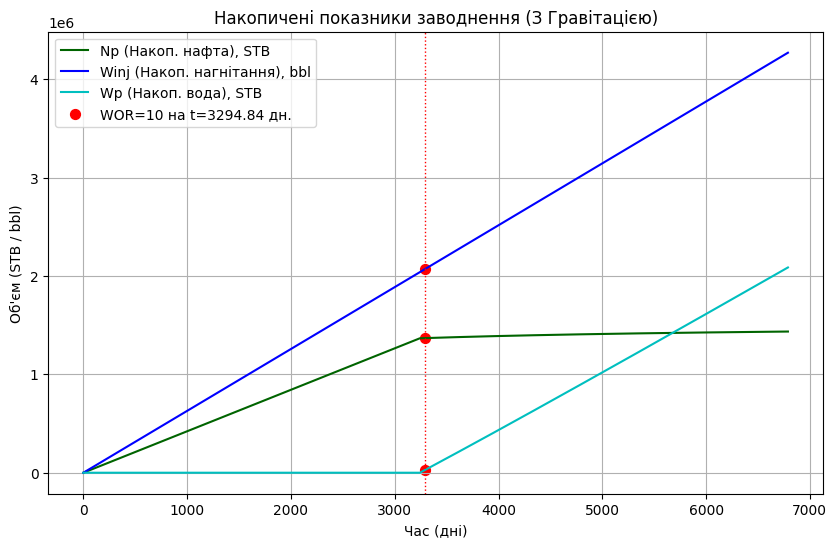

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(df_plot['Time (2wg) (days)'], df_plot['Np (2wg) (STB)'], label='Np (Накоп. нафта), STB', color='darkgreen')
plt.plot(df_plot['Time (2wg) (days)'], df_plot['Winj (2wg) (bbl)'], label='Winj (Накоп. нагнітання), bbl', color='blue')
plt.plot(df_plot['Time (2wg) (days)'], df_plot['Wp (2wg) (STB)'], label='Wp (Накоп. вода), STB', color='c')

if t_wor_10 is not None and t_wor_10 <= MAX_TIME:
    # Інтерполяція Np, Winj, Wp на час t_wor_10
    Np_wor_10 = np.interp(t_wor_10, df_plot['Time (2wg) (days)'], df_plot['Np (2wg) (STB)'])
    Winj_wor_10 = np.interp(t_wor_10, df_plot['Time (2wg) (days)'], df_plot['Winj (2wg) (bbl)'])
    Wp_wor_10 = np.interp(t_wor_10, df_plot['Time (2wg) (days)'], df_plot['Wp (2wg) (STB)'])

    plt.axvline(x=t_wor_10, color='r', linestyle=':', linewidth=1)
    plt.scatter(t_wor_10, Np_wor_10, color='r', marker='o', s=50, label=f'WOR=10 на t={t_wor_10_rounded} дн.')
    plt.scatter(t_wor_10, Winj_wor_10, color='r', marker='o', s=50)
    plt.scatter(t_wor_10, Wp_wor_10, color='r', marker='o', s=50)

plt.xlabel('Час (дні)')
plt.ylabel('Об\'єм (STB / bbl)')
plt.title('Накопичені показники заводнення (З Гравітацією)')
plt.grid(True)
plt.legend()
plt.show()

2. Показники Швидкості Видобутку ($Q_o, Q_w$)

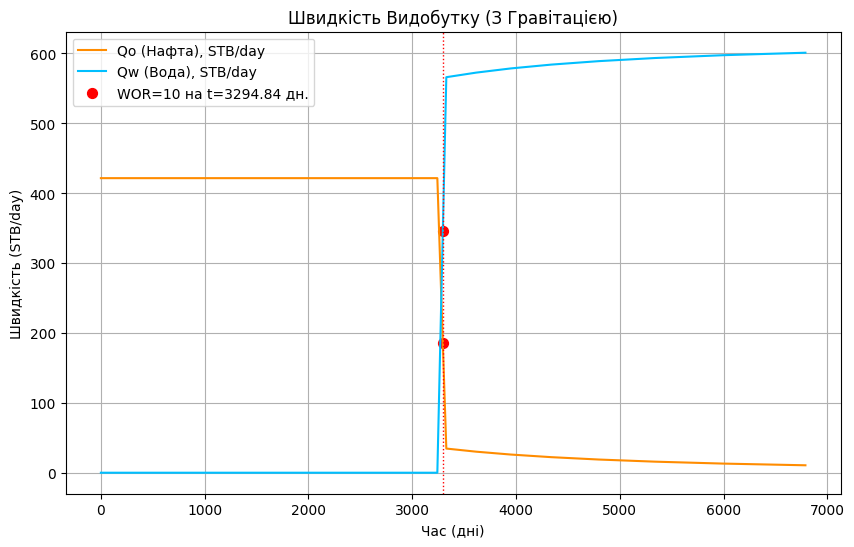

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(df_plot['Time (2wg) (days)'], df_plot['Qo (2wg) (STB/day)'], label='Qo (Нафта), STB/day', color='darkorange')
plt.plot(df_plot['Time (2wg) (days)'], df_plot['Qw (2wg) (STB/day)'], label='Qw (Вода), STB/day', color='deepskyblue')

if t_wor_10 is not None and t_wor_10 <= MAX_TIME:
    # Інтерполяція Qo, Qw на час t_wor_10
    Qo_wor_10 = np.interp(t_wor_10, df_plot['Time (2wg) (days)'], df_plot['Qo (2wg) (STB/day)'])
    Qw_wor_10 = np.interp(t_wor_10, df_plot['Time (2wg) (days)'], df_plot['Qw (2wg) (STB/day)'])

    plt.axvline(x=t_wor_10, color='r', linestyle=':', linewidth=1)
    plt.scatter(t_wor_10, Qo_wor_10, color='r', marker='o', s=50, label=f'WOR=10 на t={t_wor_10_rounded} дн.')
    plt.scatter(t_wor_10, Qw_wor_10, color='r', marker='o', s=50)

plt.xlabel('Час (дні)')
plt.ylabel('Швидкість (STB/day)')
plt.title('Швидкість Видобутку (З Гравітацією)')
plt.grid(True)
plt.legend()
plt.show()

3. Ефективність Вилучення ($E_d, Q_i$)


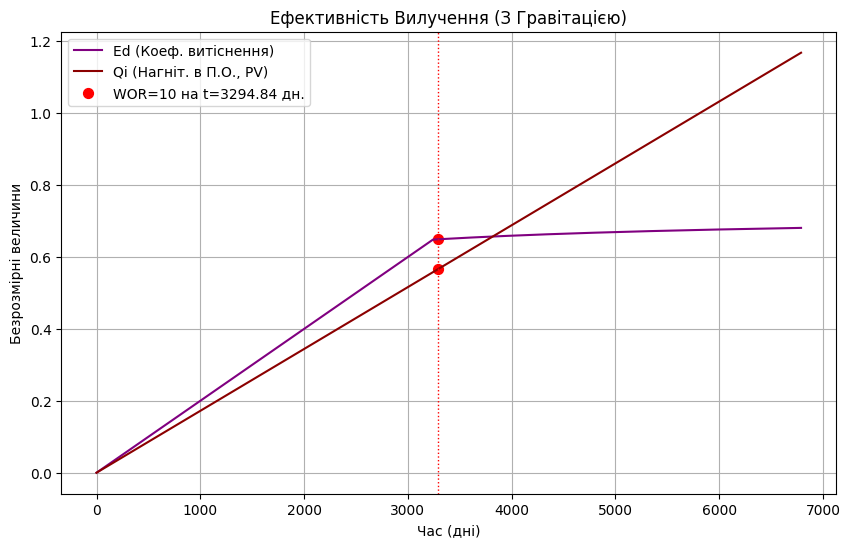

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(df_plot['Time (2wg) (days)'], df_plot['Ed (2wg) (none)'], label='Ed (Коеф. витіснення)', color='purple')
plt.plot(df_plot['Time (2wg) (days)'], df_plot['Qi (2wg) (none)'], label='Qi (Нагніт. в П.О., PV)', color='darkred')

if t_wor_10 is not None and t_wor_10 <= MAX_TIME:
    # Інтерполяція Ed, Qi на час t_wor_10
    Ed_wor_10 = np.interp(t_wor_10, df_plot['Time (2wg) (days)'], df_plot['Ed (2wg) (none)'])
    Qi_wor_10 = np.interp(t_wor_10, df_plot['Time (2wg) (days)'], df_plot['Qi (2wg) (none)'])

    plt.axvline(x=t_wor_10, color='r', linestyle=':', linewidth=1)
    plt.scatter(t_wor_10, Ed_wor_10, color='r', marker='o', s=50, label=f'WOR=10 на t={t_wor_10_rounded} дн.')
    plt.scatter(t_wor_10, Qi_wor_10, color='r', marker='o', s=50)

plt.xlabel('Час (дні)')
plt.ylabel('Безрозмірні величини')
plt.title('Ефективність Вилучення (З Гравітацією)')
plt.grid(True)
plt.legend()
plt.show()

4. Водно-нафтове Відношення ($WORs$)

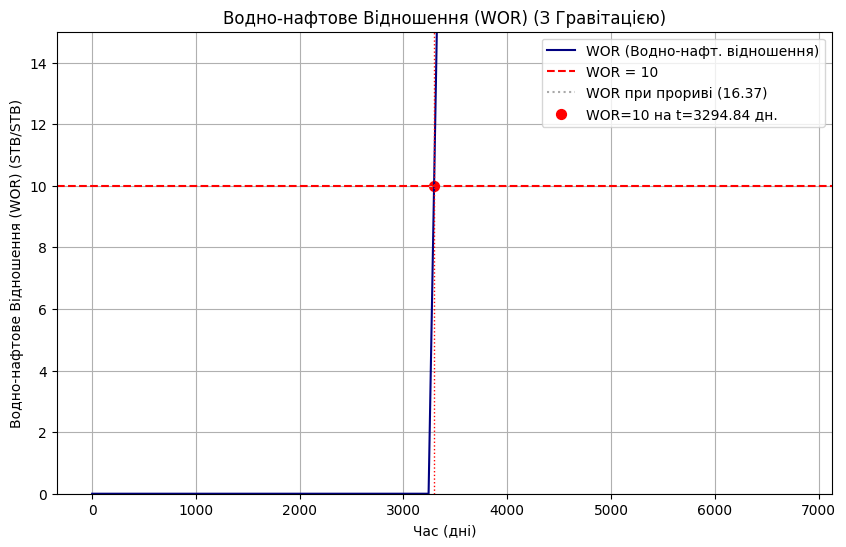

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(df_plot['Time (2wg) (days)'], df_plot['WORs (2wg) (STB/STB)'], label='WOR (Водно-нафт. відношення)', color='navy')
plt.axhline(y=10, color='red', linestyle='--', label='WOR = 10')

# Значення WOR при прориві
wor_bt = df_plot['WORs (2wg) (STB/STB)'].iloc[df_plot[df_plot['WORs (2wg) (STB/STB)'] > 0].index[0]]
plt.axhline(y=wor_bt, color='darkgray', linestyle=':', label=f'WOR при прориві ({wor_bt:.2f})')


if t_wor_10 is not None and t_wor_10 <= MAX_TIME:
    plt.axvline(x=t_wor_10, color='r', linestyle=':', linewidth=1)

    plt.scatter(t_wor_10, 10, color='red', marker='o', s=50,
                label=f'WOR=10 на t={t_wor_10_rounded} дн.')

plt.xlabel('Час (дні)')
plt.ylabel('Водно-нафтове Відношення (WOR) (STB/STB)')
plt.title('Водно-нафтове Відношення (WOR) (З Гравітацією)')
plt.ylim(0, 15) # Обмежуємо вісь Y для кращої візуалізації
plt.grid(True)
plt.legend()
plt.show()

Знайти індекс, де WOR досягає 10 (БЕЗ ГРАВІТАЦІЇ)

In [ ]:
# ===================== WOR = 10 (FINAL + Winj, Wp) =====================

target_WOR = 10

# --- 1. Знаходимо перший перетин WOR >= 10 ---
indices = np.where(WORs_2_ng >= target_WOR)[0]

if len(indices) > 0:
    idx = indices[0]

    # --- 2. Інтерполяція ---
    if idx > 0:
        i1, i2 = idx - 1, idx

        WOR1, WOR2 = WORs_2_ng[i1], WORs_2_ng[i2]
        k = (target_WOR - WOR1) / (WOR2 - WOR1)

        def interp(arr):
            return arr[i1] + k * (arr[i2] - arr[i1])

        # --- ВСІ параметри ---
        t_wor_10    = interp(t_2_ng)
        Qo_wor_10   = interp(Qo_2_ng)
        Qw_wor_10   = interp(Qw_2_ng)
        Np_wor_10   = interp(Np_2_ng)
        Ed_wor_10   = interp(Ed_2_ng)
        Qi_wor_10   = interp(Qi_2_ng)
        Winj_wor_10 = interp(Winj_2_ng)
        Wp_wor_10   = interp(Wp_2_ng)

    else:
        t_wor_10    = t_2_ng[idx]
        Qo_wor_10   = Qo_2_ng[idx]
        Qw_wor_10   = Qw_2_ng[idx]
        Np_wor_10   = Np_2_ng[idx]
        Ed_wor_10   = Ed_2_ng[idx]
        Qi_wor_10   = Qi_2_ng[idx]
        Winj_wor_10 = Winj_2_ng[idx]
        Wp_wor_10   = Wp_2_ng[idx]

    # --- Вивід ---
    print("\n=== PARAMETERS AT WOR = 10 (2ng) ===")
    print(f"Time = {t_wor_10:.2f} days")
    print(f"Qo = {Qo_wor_10:.2f}")
    print(f"Qw = {Qw_wor_10:.2f}")
    print(f"Np = {Np_wor_10:.2f}")
    print(f"Wp = {Wp_wor_10:.2f} STB")
    print(f"Winj = {Winj_wor_10:.2f} bbl")
    print(f"Ed = {Ed_wor_10:.4f}")
    print(f"Qi = {Qi_wor_10:.4f}")
    print(f"WOR = 10")

else:
    print("❗ WOR = 10 не досягнуто")


=== PARAMETERS AT WOR = 10 (2ng) ===
Time = 3138.34 days
Qo = 39.61
Qw = 558.70
Np = 1348005.85
Wp = -36481.78 STB
Winj = 1973957.13 bbl
Ed = 0.6393
Qi = 0.5398
WOR = 10


Знайти індекс, де WOR досягає 10 (З ГРАВІТАЦІЄЮ)

In [ ]:
# ===================== WOR = 10 (FINAL + Winj, Wp) =====================

target_WOR = 10

# --- 1. Знаходимо перший перетин WOR >= 10 ---
indices = np.where(WORs_2_wg >= target_WOR)[0]

if len(indices) > 0:
    idx = indices[0]

    # --- 2. Інтерполяція ---
    if idx > 0:
        i1, i2 = idx - 1, idx

        WOR1, WOR2 = WORs_2_wg[i1], WORs_2_wg[i2]
        k = (target_WOR - WOR1) / (WOR2 - WOR1)

        def interp(arr):
            return arr[i1] + k * (arr[i2] - arr[i1])

        # --- ВСІ параметри ---
        t_wor_10    = interp(t_2_wg)
        Qo_wor_10   = interp(Qo_2_wg)
        Qw_wor_10   = interp(Qw_2_wg)
        Np_wor_10   = interp(Np_2_wg)
        Ed_wor_10   = interp(Ed_2_wg)
        Qi_wor_10   = interp(Qi_2_wg)
        Winj_wor_10 = interp(Winj_2_wg)
        Wp_wor_10   = interp(Wp_2_wg)

    else:
        t_wor_10    = t_2_wg[idx]
        Qo_wor_10   = Qo_2_wg[idx]
        Qw_wor_10   = Qw_2_wg[idx]
        Np_wor_10   = Np_2_wg[idx]
        Ed_wor_10   = Ed_2_wg[idx]
        Qi_wor_10   = Qi_2_wg[idx]
        Winj_wor_10 = Winj_2_wg[idx]
        Wp_wor_10   = Wp_2_wg[idx]

    # --- Вивід ---
    print("\n=== PARAMETERS AT WOR = 10 (2ng) ===")
    print(f"Time = {t_wor_10:.2f} days")
    print(f"Qo = {Qo_wor_10:.2f}")
    print(f"Qw = {Qw_wor_10:.2f}")
    print(f"Np = {Np_wor_10:.2f}")
    print(f"Wp = {Wp_wor_10:.2f} STB")
    print(f"Winj = {Winj_wor_10:.2f} bbl")
    print(f"Ed = {Ed_wor_10:.4f}")
    print(f"Qi = {Qi_wor_10:.4f}")
    print(f"WOR = 10")

else:
    print("❗ WOR = 10 не досягнуто")


=== PARAMETERS AT WOR = 10 (2ng) ===
Time = 3328.52 days
Qo = 34.58
Qw = 566.07
Np = 1369751.58
Wp = 48981.47 STB
Winj = 2093573.38 bbl
Ed = 0.6496
Qi = 0.5725
WOR = 10
